# Análisis de Series Temporales — TodoVentas S.A ⚡️
### Predicción de Ventas Totales por País

---

## Resumen Ejecutivo

Este informe presenta un análisis de las ventas de **TodoVentas S.A**, una empresa familiar de retail online, con el objetivo de **predecir el volumen de ventas totales por país para el próximo mes**, partiendo de la última fecha disponible en los datos: el 9 de diciembre de 2023.

El análisis está estructurado en 5 bloques:

1. **Preprocesamiento y Análisis Descriptivo**: limpieza de datos, análisis de estacionalidad, descomposición de la serie temporal y análisis de autocorrelación.
2. **Desarrollo de Modelos**: Prophet, SARIMAX con variable exógena de temporada alta, y XGBoost con features de calendario y lags.
3. **Comparación y Selección de Modelo**: evaluación mediante MAPE y selección final aplicando el modelo de mejor rendimiento para cada país individualmente.
4. **Predicción**: apliación de los modelos seleccionados para realizar la previsión de ventas totales (especifiado por país) para las próximas 4 semanas.
5. **Concluisones finales**: conclusiones y evaluación final de la predicción, asi como limitaciones y recomendaciones de cara al futuro.

La predicción de ventas para el próximo mes, asciende a **£912,230** coherente con el parón estacional histórico de valle post-navideño identificado en los datos.

---

## 0. CARGADO DE LIBRERIAS NECESARIAS PARA EL PROYECTO

In [30]:
import pandas as pd
import numpy as np

from datetime import datetime, timedelta

from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA, ARIMAResults
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

import xgboost as xgb
from xgboost import plot_importance, plot_tree
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb

from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly, plot_cross_validation_metric
from prophet.diagnostics import cross_validation, performance_metrics

import plotly.io as pio
pio.renderers.default = "vscode"
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error , mean_absolute_percentage_error, root_mean_squared_error
from math import sqrt
import warnings
import itertools

import seaborn as sns
import plotly.express as px
from matplotlib import pyplot as plt

-------------
# 1. EDA

### 1.1 CARGA DE DATOS Y LIMPIEZA INICIAL

TodoVentas S.A es una empresa de retail online con presencia en múltiples mercados europeos. 
En este análisis exploraremos la evolución de sus ventas diarias entre Diciembre de 2022 y 
Diciembre de 2023, con el objetivo de construir un modelo predictivo que estime las ventas 
totales por país para el próximo mes.

Comenzamos con la carga, limpieza y exploración inicial de los datos.

In [31]:
df = pd.read_csv("retail_todo_ventas.csv", low_memory=False)
prod_dict = pd.read_csv("prod_dict.csv")

# Elimino filas duplicadas en prod_dict para evitar multiplicar filas en el merge
prod_dict = prod_dict.drop_duplicates(subset='StockCode', keep='first')
df = df.merge(prod_dict, on='StockCode', how='left')
print(f'Shape tras merge limpio: {df.shape}')



# Cambio tipo de fecha
df["Date"] = pd.to_datetime(df["Date"])

# Quito cancelaciones (InvoiceNo que comienzan por 'C')
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")].copy()


print(f"Shape tras limpieza: {df.shape}")
print(f"Rango temporal: {df['Date'].min()} → {df['Date'].max()}")
print(f"Países únicos: {df['Country'].nunique()}")
df.head()

Shape tras merge limpio: (394330, 6)
Shape tras limpieza: (394330, 6)
Rango temporal: 2022-12-01 00:00:00 → 2023-12-09 00:00:00
Países únicos: 10


,InvoiceNo,StockCode,Date,Country,TotalSales,Description
0,536365,21730,2022-12-01,United Kingdom,25.50,GLASS STAR FROSTED T-LIGHT HOLDER
1,536365,22752,2022-12-01,United Kingdom,15.30,SET 7 BABUSHKA NESTING BOXES
2,536365,71053,2022-12-01,United Kingdom,20.34,WHITE METAL LANTERN
3,536365,84029E,2022-12-01,United Kingdom,20.34,RED WOOLLY HOTTIE WHITE HEART.
4,536365,84029G,2022-12-01,United Kingdom,20.34,KNITTED UNION FLAG HOT WATER BOTTLE


--------------

### 1.2 ANÁLISIS DESCRIPTIVO GENERAL

In [32]:
print("RESUMEN DEL DATASET")
print(f"  Filas:              {df.shape[0]:>10,}")
print(f"  Columnas:           {df.shape[1]:>10}")
print(f"  Rango temporal:     {df['Date'].min().date()} : {df['Date'].max().date()}")
print(f"  Países:             {df['Country'].nunique():>10}")
print(f"  Productos únicos:   {df['StockCode'].nunique():>10,}")
print(f"  Ventas totales (en moneda de UK): {df['TotalSales'].sum():>10,.2f}")
print()

# Nulos
print("VALORES NULOS")
display(df.isnull().sum().to_frame("Nulos"))

# Estadísticas de ventas
print("\nESTADÍSTICAS DE VENTAS")
display(df["TotalSales"].describe().to_frame())

RESUMEN DEL DATASET
  Filas:                 394,330
  Columnas:                    6
  Rango temporal:     2022-12-01 : 2023-12-09
  Países:                     10
  Productos únicos:        3,697
  Ventas totales (en moneda de UK): 9,656,548.16

VALORES NULOS


,Nulos
InvoiceNo,0
StockCode,0
Date,0
Country,0
TotalSales,0
Description,0



ESTADÍSTICAS DE VENTAS


,TotalSales
count,394330.000000
mean,24.488495
std,103.726861
min,0.000000
25%,7.380000
50%,13.520000
75%,19.900000
max,38970.000000


Al tener como dato minimo en TotalSales 0, voy a ver si corresponde a los domingos y dias festivos o dias suelto que pueda ser problematico. Además así podré saber los dias de vacaciones de la empresa.

In [33]:
#Agrupo por fecha sumando las ventas
ventas_diarias = df.groupby("Date")["TotalSales"].sum()

#Creo el calendario completo ('D' = Diario) y rellenamos los huecos con 0
ventas_diarias = ventas_diarias.asfreq('D', fill_value=0).reset_index()

# Aplico el filtro de días con ventas menores a 100£
dias_bajos = ventas_diarias[ventas_diarias["TotalSales"] < 100]

print(f"Hemos encontrado {len(dias_bajos)} días con ventas menores a 100£:")
display(dias_bajos.head(10))

Hemos encontrado 69 días con ventas menores a 100£:


,Date,TotalSales
3,2022-12-04,0.0
10,2022-12-11,0.0
17,2022-12-18,0.0
23,2022-12-24,0.0
24,2022-12-25,0.0
25,2022-12-26,0.0
26,2022-12-27,0.0
27,2022-12-28,0.0
28,2022-12-29,0.0
29,2022-12-30,0.0


In [34]:
dias_bajos = dias_bajos.copy()
dias_bajos["Dia_Semana"] = dias_bajos["Date"].dt.day_name()
domingos = dias_bajos[dias_bajos["Dia_Semana"] == "Sunday"]
otros_dias = dias_bajos[dias_bajos["Dia_Semana"] != "Sunday"]

print(f"De los {len(dias_bajos)} días sin apenas ventas:")
print(f"- {len(domingos)} son Domingos (cerrado habitualmente).")
print(f"- {len(otros_dias)} son Otros días de la semana.\n")

print("--- LOS DÍAS QUE NO SON DOMINGO ---")
display(otros_dias)

De los 69 días sin apenas ventas:
- 53 son Domingos (cerrado habitualmente).
- 16 son Otros días de la semana.

--- LOS DÍAS QUE NO SON DOMINGO ---


,Date,TotalSales,Dia_Semana
23,2022-12-24,0.0,Saturday
25,2022-12-26,0.0,Monday
26,2022-12-27,0.0,Tuesday
27,2022-12-28,0.0,Wednesday
28,2022-12-29,0.0,Thursday
29,2022-12-30,0.0,Friday
30,2022-12-31,0.0,Saturday
32,2023-01-02,0.0,Monday
33,2023-01-03,0.0,Tuesday
142,2023-04-22,0.0,Saturday


Tal y como se aprecia en la tabla, la empresa está cerrada en el periodo de navidad entre los dias 2022-12-24 y 2023-01-03.

En Abril hay varios dias que no hay ventas, al igual que en mayo y un dia en agosto. Hay que analizar de donde puede venir esto, o tratarlo como ruido. En este caso, trás hacer una investigación, he podido saber que en Reino Unido (que es de donde son la mayoría de ventas), estas fechas coinciden con "Bank Holidays" (días festivos nacionales).

---------------

### 1.3 DISTRIBUCIÓN DE VENTAS POR PAÍS

Analizamos el peso relativo de cada mercado. Esto es clave para decidir sobre qué países tiene sentido construir modelos individuales y cuáles podríamos agrupar por volumen reducido.

In [35]:
ventas_pais = (
    df.groupby("Country")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
ventas_pais["Porcentaje (%)"] = (
    ventas_pais["TotalSales"] / ventas_pais["TotalSales"].sum() * 100
).round(1)

display(ventas_pais)

# Gráfico de barras por país con escala logarítmica (para poder leer los datos correctamente) en el eje Y
fig = px.bar(
    ventas_pais,
    x="Country", y="TotalSales",
    title="Ventas Totales por País (Dic 2022 – Dic 2023)",
    text="Porcentaje (%)",
    color="TotalSales",
    color_continuous_scale="Blues",
    labels={"TotalSales": "Ventas Totales (en escala logarítmica)", "Country": "País"}
)
fig.update_traces(texttemplate="%{text}%", textposition="inside")
fig.update_layout(coloraxis_showscale=False, xaxis_tickangle=-30, yaxis_type="log")
fig.show()

,Country,TotalSales,Porcentaje (%)
0,United Kingdom,8555662.571,88.6
1,Netherlands,261986.880,2.7
2,EIRE,261750.070,2.7
3,Germany,210139.590,2.2
4,France,192274.730,2.0
5,Spain,55980.350,0.6
6,Belgium,36806.580,0.4
7,Sweden,36024.690,0.4
8,Portugal,30933.430,0.3
9,Italy,14989.270,0.2


Claramente, es Reino Unido donde están la mayor parte de las ventas de TodoVentas S.A., donde se concrentran el 88,6% de ellas.



----------------


### 1.4 EVOLUCIÓN TEMPORAL

He decidido hacer una agrupación semanal, ya que me va a permitir observar una tendencia reprensentativa de los datos sin el ruido y distorsiones que pueden generar un día aislado. 

In [36]:
# Serie mensual de todos los países
df_total = (
    df.groupby(pd.Grouper(key="Date", freq="W"))["TotalSales"]
    .sum()
    .reset_index()
    .rename(columns={"Date": "Semana"})
)

print(f"Puntos en la serie mensual total: {len(df_total)}")
display(df_total)

# Visualización serie total
df_total_plot = df_total[df_total["Semana"] < "2023-12-11"]
fig = px.line(
    df_total_plot, x="Semana", y="TotalSales",
    title="Evolución Semanal de Ventas Totales — TodoVentas S.A.",
    markers=True,
    labels={"Ventas totates": "Ventas (£)", "Semana": "Fecha"}
)

fig.update_layout(hovermode="x unified")
fig.show()

Puntos en la serie mensual total: 54


,Semana,TotalSales
0,2022-12-04,146781.460
1,2022-12-11,326157.690
2,2022-12-18,212282.110
3,2022-12-25,95548.660
4,2023-01-01,0.000
5,2023-01-08,107466.510
6,2023-01-15,192347.210
7,2023-01-22,124019.000
8,2023-01-29,113256.460
9,2023-02-05,122385.780


- Tal y como se comentó en el 1.2 Analasis descriptivo general, la semana del periodo de vacaciones de Navidad se aprecia claramente en la gráfica.
- También se aprecia bajadas de en el periodo de los dias sin ventas de abril que hablamos anteriormente. Una conclusión rápida que se puede sacar es la importancia de cada día cerrado el negocio, tiene una implicación directa y destacada en la evolución de las ventas totales de la empresa.

---------------------

### 1.5 DESCOMPOSICIÓN DE LA SERIE TEMPORAL

Separamos la serie en sus tres componentes para entender qué está impulsando las ventas:

- **Tendencia:** ¿las ventas crecen, decrecen o se mantienen estables?
- **Estacionalidad:** ¿hay meses donde siempre se vende más? (p.ej. Navidad)
- **Residuo:** lo que no explican los dos anteriores — ruido aleatorio

Usamos el modelo **aditivo** (Tendencia + Estacionalidad + Residuo = Serie original), apropiado cuando la amplitud estacional no cambia con el nivel de la serie.

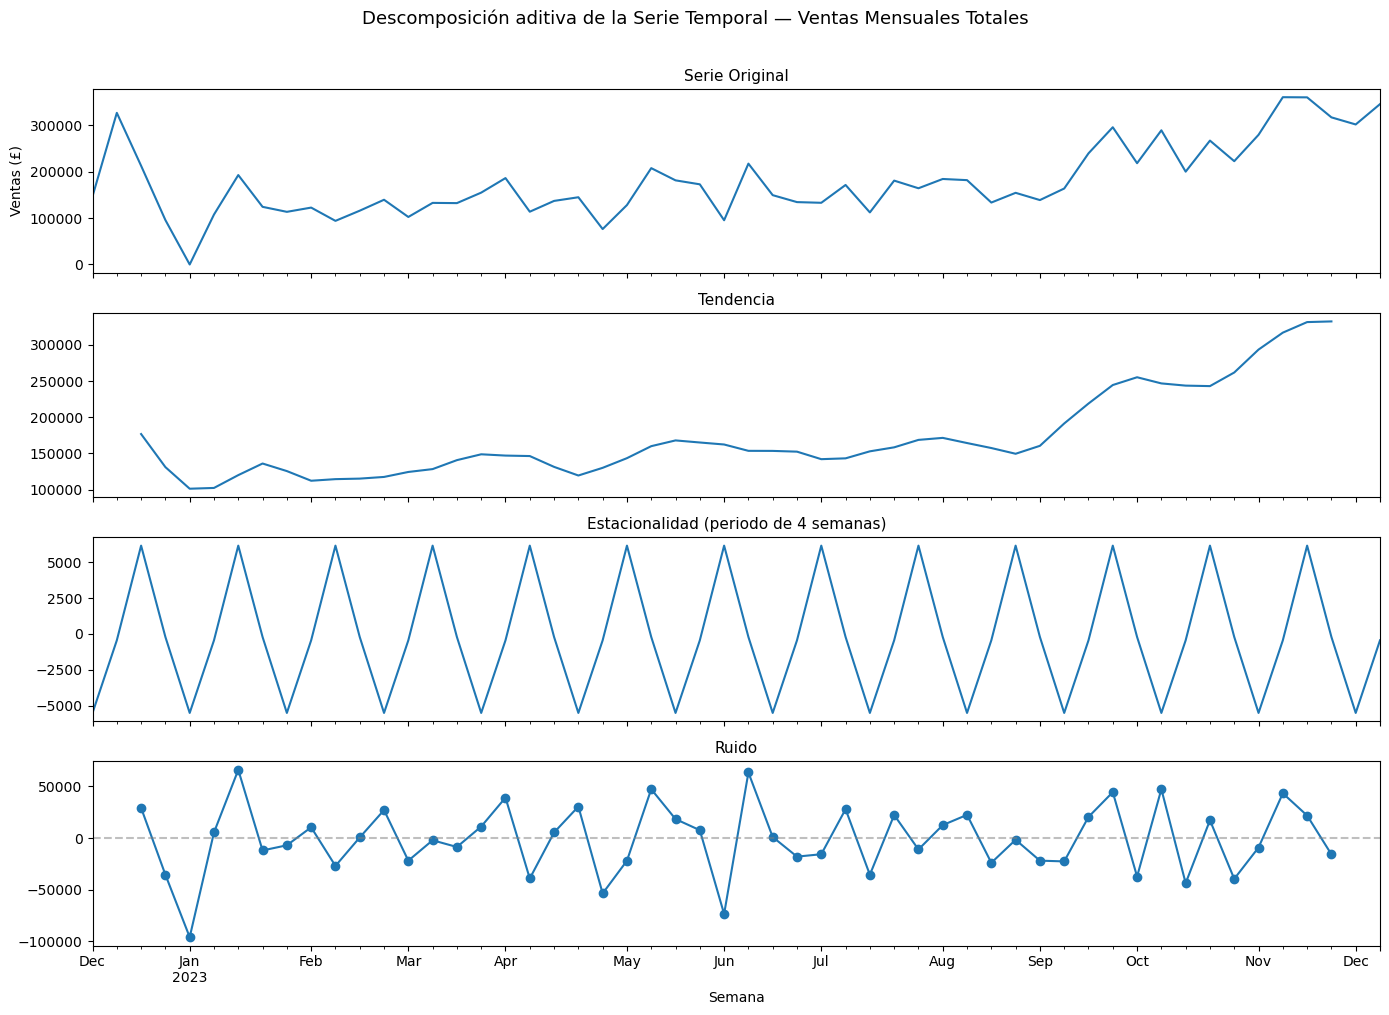

In [37]:
serie = df_total.set_index("Semana")["TotalSales"]
descomposicion = seasonal_decompose(serie.dropna(), model="additive", period=4)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

descomposicion.observed.plot(ax=axes[0])
axes[0].set_title("Serie Original", fontsize=11)
axes[0].set_ylabel("Ventas (£)")

descomposicion.trend.plot(ax=axes[1])
axes[1].set_title("Tendencia", fontsize=11)

descomposicion.seasonal.plot(ax=axes[2])
axes[2].set_title("Estacionalidad (periodo de 4 semanas)", fontsize=11)


descomposicion.resid.plot(ax=axes[3], marker="o")
axes[3].set_title("Ruido", fontsize=11)
axes[3].axhline(0, linestyle="--", color="gray", alpha=0.5)

plt.suptitle("Descomposición aditiva de la Serie Temporal — Ventas Mensuales Totales",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

La descomposición aditiva revela tres hallazgos clave:

**Tendencia:** ascendente, con una caída post-navideña en enero 2023 seguida de un crecimiento sostenido que se acelera en el último trimestre. Este patrón es positivo de cara a la valoración de la empresa.

**Estacionalidad:** patrón mensual, muy regular con periodo de 4 semanas y amplitud de ±4.000 £, confirmando la elección del modelo aditivo, pues la amplitud estacional no varía con el nivel de ventas.

**Ruido:** el ruido nos confirma lo que hemos descubierto previamente, en enero 2023 (valle post-navideño). El pido de junio 2023 (pico puntual) son valores atípicos, que serán gestionados por los modelos de forma diferente.

-----------------

### 1.6 TEST DE ESTACIONARIEDAD — ADF Test

Para las series temporales es clave la **estacionariedad**: una serie es estacionaria cuando su media y varianza no cambian con el tiempo.

Usamos el **Test de Dickey-Fuller Aumentado (ADF)**:
- Si el p-valor < 0.05 → la serie **SÍ** es estacionaria.
- Si el p-valor ≥ 0.05 → necesitamos **diferenciar** la serie.

p-valor: 0.9875

Serie NO estacionaria — el modelo necesitará diferenciación


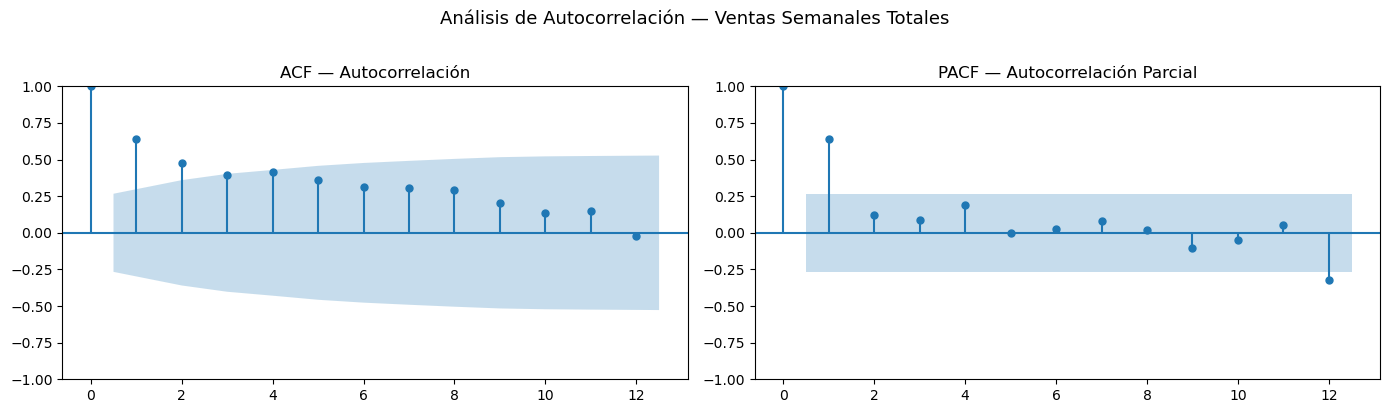

In [38]:
serie = df_total.set_index("Semana")["TotalSales"]

# ADF Test
resultado_adf = adfuller(serie.dropna())
print(f"p-valor: {resultado_adf[1]:.4f}")

print()
if resultado_adf[1] < 0.05:
    print("Serie ESTACIONARIA — podemos modelar directamente")
else:
    print("Serie NO estacionaria — el modelo necesitará diferenciación")

# ACF y PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(serie.dropna(), lags=12, ax=axes[0], title="ACF — Autocorrelación")
plot_pacf(serie.dropna(), lags=12, ax=axes[1], title="PACF — Autocorrelación Parcial", method="ywm")

plt.suptitle("Análisis de Autocorrelación — Ventas Semanales Totales", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

La serie **NO** es estacionaria, lo que significa que la media de las ventas cambia con el tiempo (hay tendencia)

----------------------------
----------------------------

# 2. MODELOS PREDICTIVOS

Para abordar la predicción de ventas mensuales entrenamos los modelos con datos semanales y comprobamos su eficacia con las cuatro ultimas semanas de los datos (1 mes) para obtener la estimación mensual final.

Evaluamos tres modelos:
- **Prophet** 
- **SARIMAX** 
- **XGBoost** 

Tal y como se indica en el ejercicio, se pide predicciones por país. Dado que el dataset presenta una fuerte concentración de ventas en Reino Unido (88.6%), voy hacer la siguiente estrategia:

- **Modelos individuales** para UK, EIRE, Alemania y Francia. Mercados con series completas (50+ semanas) que representan el 98.1% de las ventas.

- **Modelo común** para el resto de mercados (Países Bajos, España, Bélgica, Suecia, Portugal e Italia). Series demasiado cortas o irregulares para modelado individual fiable. Se agrupan como "Resto de Europa" y se aplica un modelo único.



In [39]:
# DEFINICIÓN DE GRUPOS DE PAÍSES
PAISES_PRINCIPALES = ['United Kingdom', 'EIRE', 'Germany', 'France']
PAISES_RESTO = ['Netherlands', 'Spain', 'Belgium', 'Sweden', 'Portugal', 'Italy']
TEST_WEEKS = 4  # Reservamos 4 semanas como test (1 mes)

# DF DE PAISES PRINCIPALES
df_pais = (
    df[df['Country'].isin(PAISES_PRINCIPALES)]
    .groupby(['Country', pd.Grouper(key='Date', freq='W')])['TotalSales']
    .sum()
    .reset_index()
    .rename(columns={'Date': 'Semana'})
)

# DF DE RESTO DE EUROPA
df_resto = (
    df[df['Country'].isin(PAISES_RESTO)]
    .groupby(pd.Grouper(key='Date', freq='W'))['TotalSales']
    .sum()
    .reset_index()
    .rename(columns={'Date': 'Semana'})
)
df_resto['Country'] = 'Resto Europa'

# UNO AMBOS DF
df_todos = pd.concat([df_pais, df_resto], ignore_index=True)

# VERIFICO SEMANAS DISPONIBLES POR GRUPO
print("Semanas disponibles por grupo:")
for grupo in df_todos['Country'].unique():
    n = len(df_todos[df_todos['Country'] == grupo])
    print(f"  {grupo:<20} {n} semanas")

Semanas disponibles por grupo:
  EIRE                 50 semanas
  France               53 semanas
  Germany              53 semanas
  United Kingdom       53 semanas
  Resto Europa         54 semanas


## 2.1 ESTANDARIZACIÓN

Tengo que hacer esto, para que todas las semanas tengan los datos completos. Para ello, **los datos faltantes los voy a rellenar con 0** debido a que, tras comprobar los dias con información faltante, corresponden al periodo vacacional, y los domingos, y algunos días a mitad de abril que pueden corresponder con alguna fiesta local o nacional. 

Por lo tanto, si la decisión hubiera sido sustituirlos por la media, la moda, la mediana o el valor conocido anterior o posterior, caeriamos en una inflacción de estos valores y por lo tanto, una distorsión de los resultados. Además, **los modelos predictivos que voy a utilizar a continuación, voy a añadirle la variable exógena (periodo vacaional de navidades)**, para que sea consciente de esto, y ante datos anomalos (ruido) tienen estos modelos capacidad de adaptación.

In [40]:
# 1. Creamos una "tabla dinámica" para forzar que todos compartan el mismo calendario
df_pivot = df_todos.pivot(index='Semana', columns='Country', values='TotalSales')

# 2. Al hacer esto, las semanas donde un país no vendió aparecerán como "NaN" (Not a Number). 
# Las rellenamos con 0.
df_pivot = df_pivot.fillna(0)

# 3. Volvemos a aplanar la tabla a su formato original (3 columnas: Semana, Country, TotalSales)
df_estandarizado = df_pivot.reset_index().melt(id_vars='Semana', value_name='TotalSales')

# VERIFICACIÓN FINAL: Comprobamos si ahora todos tienen las mismas semanas
print("Semanas estandarizadas por grupo:")
for grupo in df_estandarizado['Country'].unique():
    n = len(df_estandarizado[df_estandarizado['Country'] == grupo])
    print(f"  {grupo:<20} {n} semanas")

Semanas estandarizadas por grupo:
  EIRE                 54 semanas
  France               54 semanas
  Germany              54 semanas
  Resto Europa         54 semanas
  United Kingdom       54 semanas


## 2.2 DIVISIÓN TRAIN / TEST

Reservamos las últimas **4 semanas** como conjunto de test (equivalente a 1 mes), que usaremos para evaluar todos los modelos con las mismas métricas y en igualdad de condiciones.

In [41]:
# 1. Obtenemos la lista de todas las semanas ordenadas cronológicamente
fechas_ordenadas = df_estandarizado['Semana'].sort_values().unique()

# 2. Buscamos la fecha exacta donde debemos dar el "hachazo" (4 semanas antes del final)
fecha_corte = fechas_ordenadas[-TEST_WEEKS]

df_train = df_estandarizado[df_estandarizado['Semana'] < fecha_corte].copy()
df_test = df_estandarizado[df_estandarizado['Semana'] >= fecha_corte].copy()

# 4. Comprobación
semanas_train = len(df_train['Semana'].unique())
semanas_test = len(df_test['Semana'].unique())
print(f"Semanas para entrenar (Train): {semanas_train} semanas por país.")
print(f"Semanas para examinar (Test): {semanas_test} semanas por país.")

Semanas para entrenar (Train): 50 semanas por país.
Semanas para examinar (Test): 4 semanas por país.


## 2.2 PROPHET

In [42]:
paises = df_train['Country'].unique()

for pais in paises:
    #Filtro la tabla para quedarme solo con las filas de cada país
    df_pais = df_train[df_train['Country'] == pais].copy()
    
    prophet_df = df_pais.rename(columns={"Semana": "ds", "TotalSales": "y"})
    prophet_df = prophet_df[["ds", "y"]]
    
    #Comprobación
    print(f"Datos listos para: -- {pais} --")
    print(f"Rango: {prophet_df['ds'].min().date()} → {prophet_df['ds'].max().date()}")
    print(f"Total semanas: {len(prophet_df)}")
    display(prophet_df.head(2))
    print("\n")

Datos listos para: -- EIRE --
Rango: 2022-12-04 → 2023-11-12
Total semanas: 50


,ds,y
0,2022-12-04,2847.82
1,2022-12-11,2928.30




Datos listos para: -- France --
Rango: 2022-12-04 → 2023-11-12
Total semanas: 50


,ds,y
54,2022-12-04,1164.30
55,2022-12-11,5582.57




Datos listos para: -- Germany --
Rango: 2022-12-04 → 2023-11-12
Total semanas: 50


,ds,y
108,2022-12-04,882.66
109,2022-12-11,6705.01




Datos listos para: -- Resto Europa --
Rango: 2022-12-04 → 2023-11-12
Total semanas: 50


,ds,y
162,2022-12-04,1460.0
163,2022-12-11,1819.6




Datos listos para: -- United Kingdom --
Rango: 2022-12-04 → 2023-11-12
Total semanas: 50


,ds,y
216,2022-12-04,140426.68
217,2022-12-11,309122.21


In [43]:
bank_holidays = pd.DataFrame({
    "holiday": "Bank Holiday UK",
    "ds": pd.to_datetime([
        "2022-12-24", "2022-12-25", "2022-12-26", "2022-12-27", "2022-12-28",
        "2022-12-29", "2022-12-30", "2023-01-01", "2023-01-02", "2023-01-03",
        "2023-04-07", "2023-04-10", "2023-05-01", "2023-05-08", "2023-05-29",
        "2023-08-28",
    ]),
    "lower_window": -1,
    "upper_window": 1,
})

# FUNCIÓN: AÑADIR REGRESOR DE TEMPORADA ALTA
def añadir_regresor_temporada(df_prophet):
    
    df_prophet['temporada_alta'] = df_prophet['ds'].dt.month.isin([11, 12]).astype(int)
    return df_prophet

# ENTRENAMIENTO
warnings.filterwarnings("ignore")

modelos_prophet      = {}
predicciones_prophet = {}
grupos = df_train['Country'].unique()

for grupo in grupos:
    # 1. DATOS DE ENTRENAMIENTO
    df_grupo_train = df_train[df_train['Country'] == grupo].copy()
    prophet_train  = df_grupo_train.rename(
        columns={"Semana": "ds", "TotalSales": "y"})[["ds", "y"]]
    prophet_train  = añadir_regresor_temporada(prophet_train)

    # 2. MODELO — añadimos add_regressor antes de fit()
    modelo = Prophet(
        holidays                = bank_holidays,
        seasonality_mode        = "additive",
        weekly_seasonality      = True,
        yearly_seasonality      = False,
        
    )
    modelo.add_regressor('temporada_alta')
    modelo.fit(prophet_train)
    modelos_prophet[grupo] = modelo

    future_df = modelo.make_future_dataframe(periods=TEST_WEEKS, freq="W")
    future_df = añadir_regresor_temporada(future_df) 
    prediccion = modelo.predict(future_df)
    predicciones_prophet[grupo] = prediccion

    print(f" {grupo:<20} | train: {len(prophet_train)} semanas "
          f"| semanas temporada alta en train: "
          f"{prophet_train['temporada_alta'].sum()}")

17:33:04 - cmdstanpy - INFO - Chain [1] start processing
17:33:05 - cmdstanpy - INFO - Chain [1] done processing
17:33:05 - cmdstanpy - INFO - Chain [1] start processing


 EIRE                 | train: 50 semanas | semanas temporada alta en train: 6


17:33:05 - cmdstanpy - INFO - Chain [1] done processing
17:33:06 - cmdstanpy - INFO - Chain [1] start processing


 France               | train: 50 semanas | semanas temporada alta en train: 6


17:33:06 - cmdstanpy - INFO - Chain [1] done processing
17:33:06 - cmdstanpy - INFO - Chain [1] start processing


 Germany              | train: 50 semanas | semanas temporada alta en train: 6


17:33:06 - cmdstanpy - INFO - Chain [1] done processing
17:33:07 - cmdstanpy - INFO - Chain [1] start processing


 Resto Europa         | train: 50 semanas | semanas temporada alta en train: 6


17:33:07 - cmdstanpy - INFO - Chain [1] done processing


 United Kingdom       | train: 50 semanas | semanas temporada alta en train: 6


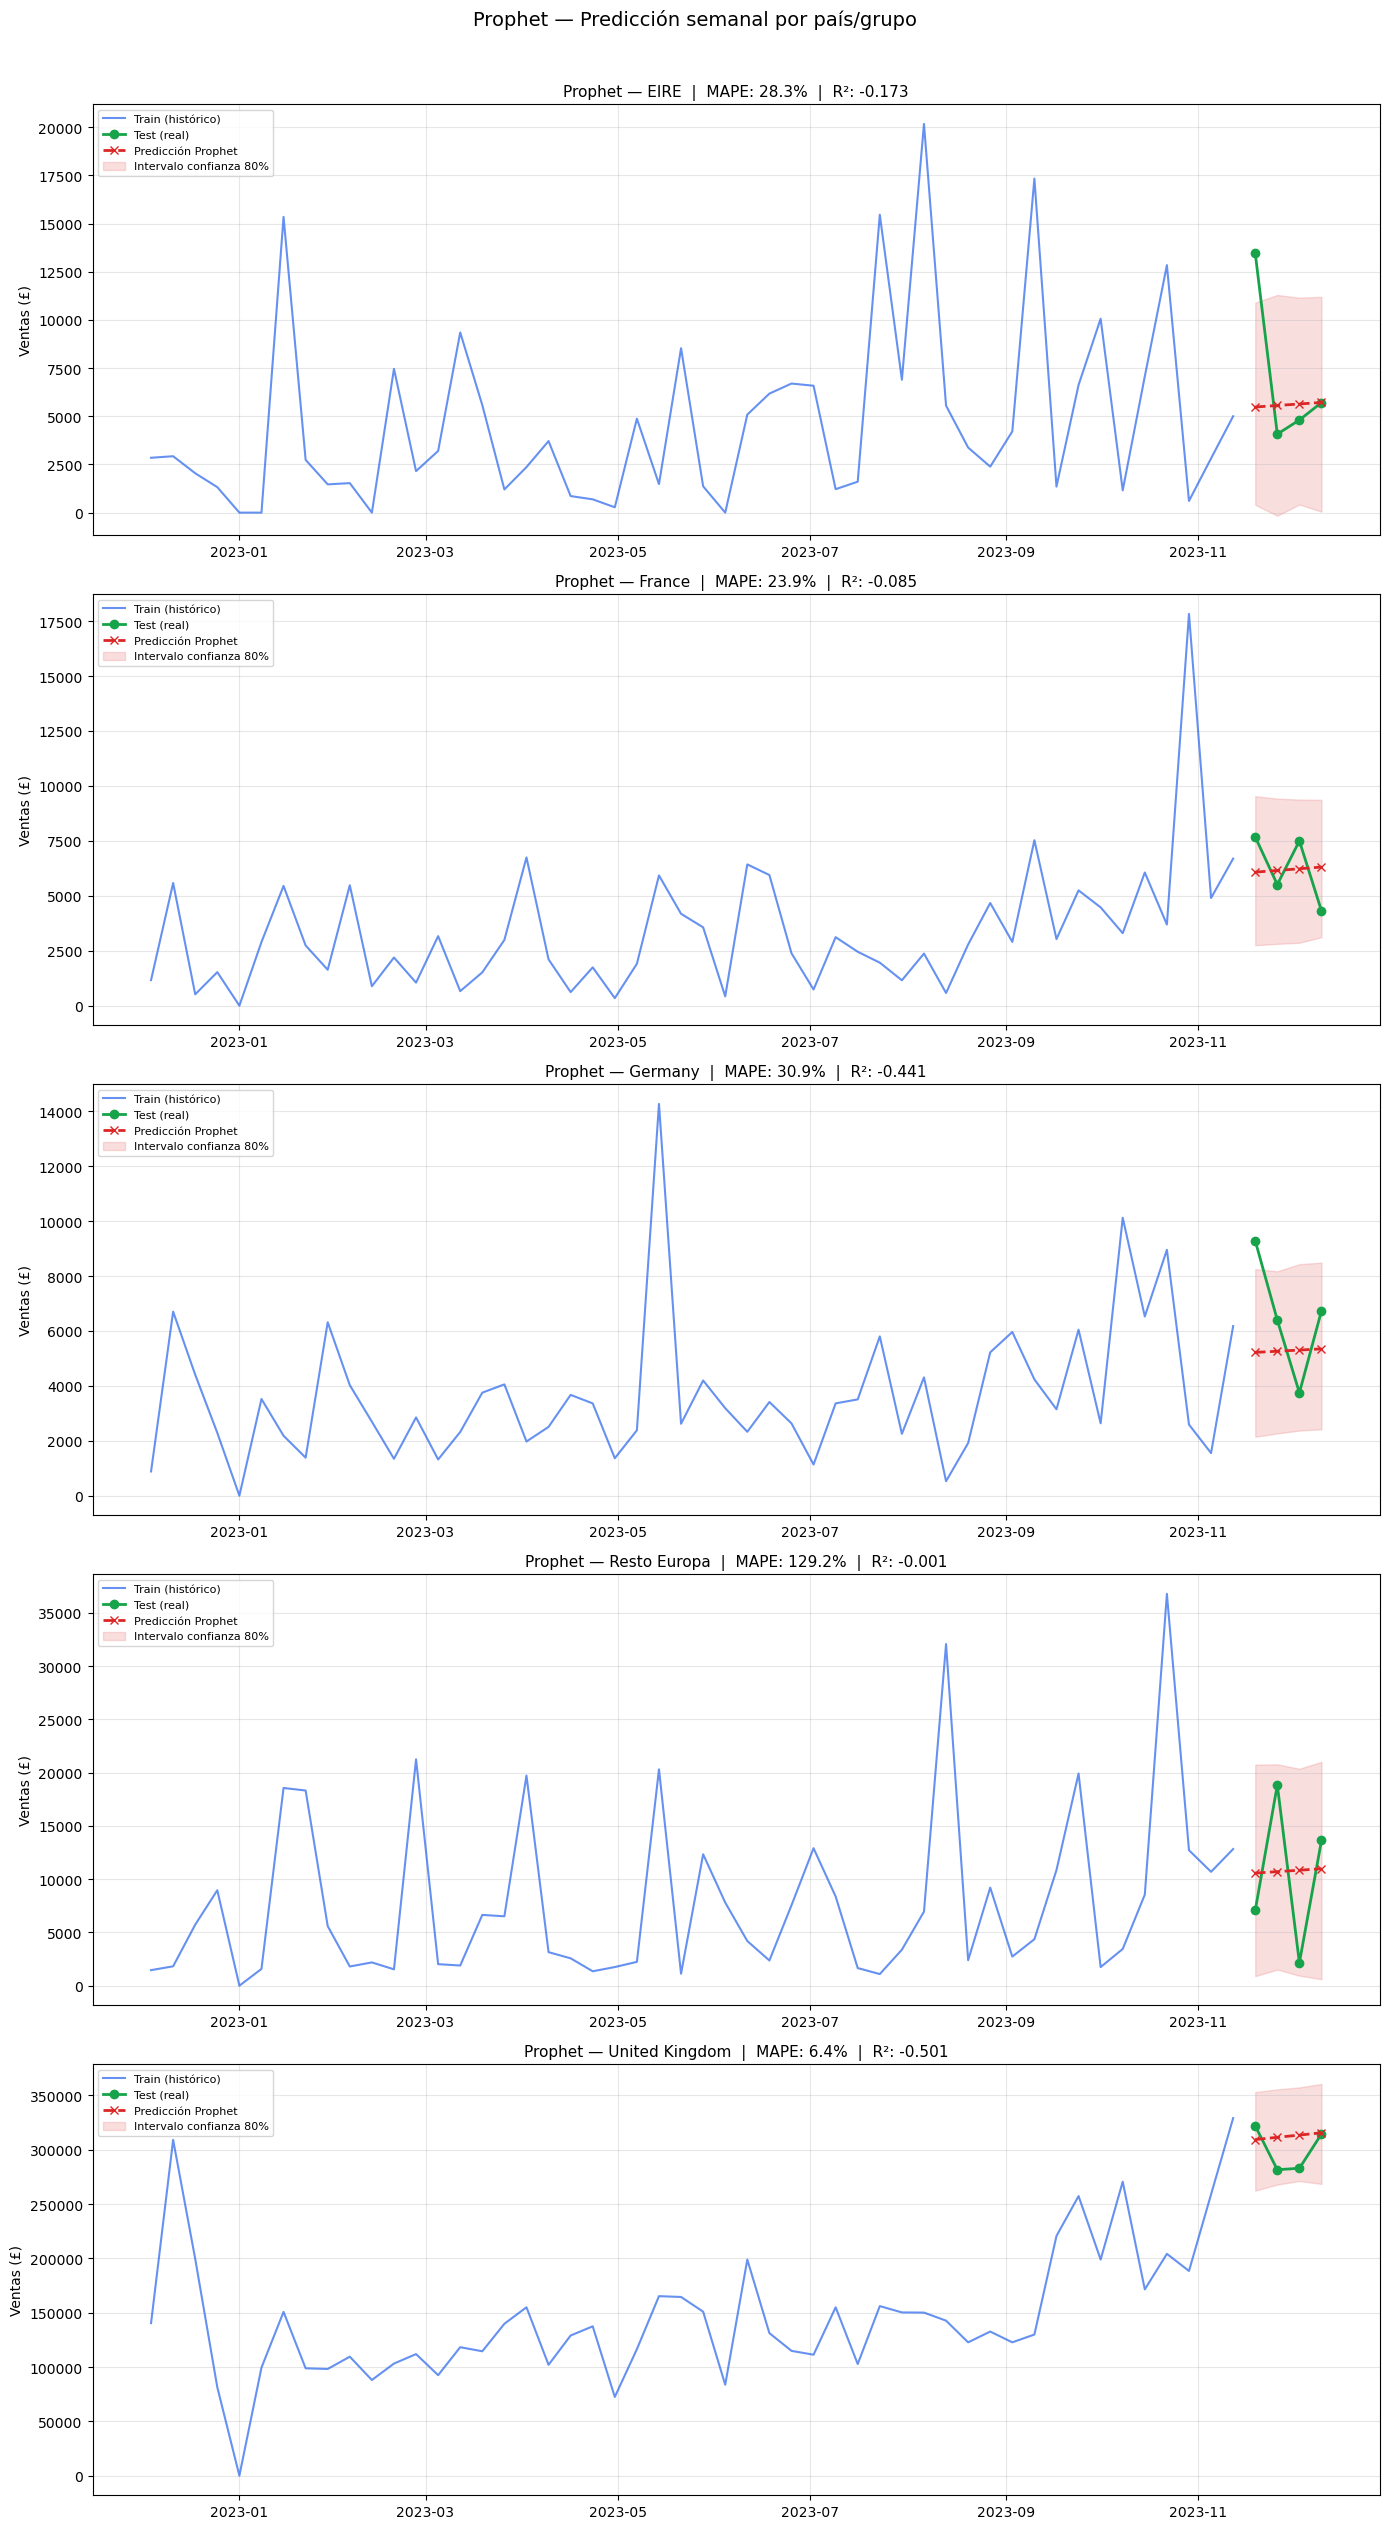

  RESUMEN PROPHET — PREDICCIÓN MENSUAL POR PAÍS


,País,MAE,RMSE,MAPE (%),R²,Real Mensual,Pred Mensual
0,EIRE,2576.202396,4080.490674,28.28,-0.173,28062.0,22403.0
1,France,1376.281751,1462.687378,23.89,-0.085,25007.0,24770.0
2,Germany,2036.661293,2354.976499,30.91,-0.441,26171.0,21135.0
3,Resto Europa,5751.027602,6349.149170,129.24,-0.001,41698.0,43101.0
4,United Kingdom,18514.641175,22270.566820,6.41,-0.501,1201206.0,1250082.0



  Total real empresa  : £   1,322,144
  Total predicho      : £   1,361,491
  Diferencia          : £      39,347  (3.0%)


In [44]:
#EVALUACIÓN Y VISUALIZACIÓN POR PAÍS
resumen_prophet = []

fig, axes = plt.subplots(len(grupos), 1, figsize=(14, 5 * len(grupos)))

for i, grupo in enumerate(grupos):
    ax = axes[i]

    # Datos reales test
    df_grupo_test = df_test[df_test['Country'] == grupo].copy()
    y_real        = df_grupo_test['TotalSales'].values

    # Predicción — últimas TEST_WEEKS filas de yhat
    prediccion  = predicciones_prophet[grupo]
    y_predicho  = prediccion.tail(TEST_WEEKS)['yhat'].values

    # Métricas
    mae  = mean_absolute_error(y_real, y_predicho)
    rmse = root_mean_squared_error(y_real, y_predicho)
    mape = mean_absolute_percentage_error(y_real, y_predicho) * 100
    r2   = r2_score(y_real, y_predicho)

    # Predicción mensual agregada (bottom-up: suma de 4 semanas)
    pred_mensual = prediccion.tail(TEST_WEEKS)['yhat'].sum()
    real_mensual = y_real.sum()

    resumen_prophet.append({
        "País":          grupo,
        "MAE":           mae,
        "RMSE":          rmse,
        "MAPE (%)":      round(mape, 2),
        "R²":            round(r2, 3),
        "Real Mensual":  round(real_mensual, 0),
        "Pred Mensual":  round(pred_mensual, 0),
    })

    # Gráfico: histórico train + test real + predicción
    df_grupo_train = df_train[df_train['Country'] == grupo]
    ax.plot(df_grupo_train['Semana'], df_grupo_train['TotalSales'],
            label='Train (histórico)', color='#2563EB', linewidth=1.5, alpha=0.7)
    ax.plot(df_grupo_test['Semana'], y_real,
            label='Test (real)', color='#16A34A', linewidth=2, marker='o')
    ax.plot(df_grupo_test['Semana'], y_predicho,
            label='Predicción Prophet', color='#DC2626',
            linewidth=2, linestyle='--', marker='x')

    # Intervalo de confianza
    forecast_tail = prediccion.tail(TEST_WEEKS)
    ax.fill_between(forecast_tail['ds'],
                    forecast_tail['yhat_lower'],
                    forecast_tail['yhat_upper'],
                    alpha=0.15, color='#DC2626', label='Intervalo confianza 80%')

    ax.set_title(f"Prophet — {grupo}  |  MAPE: {mape:.1f}%  |  R²: {r2:.3f}", fontsize=11)
    ax.set_ylabel("Ventas (£)")
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Prophet — Predicción semanal por país/grupo", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── RESUMEN FINAL ─────────────────────────────────────────────────────────────
resultados_prophet = {}
for _, row in pd.DataFrame(resumen_prophet).iterrows():
    resultados_prophet[row['País']] = {
        'metricas': {
            'MAE':  row['MAE'],
            'RMSE': row['RMSE'],
            'MAPE': row['MAPE (%)'],
            'R2':   row['R²'],
        },
        'pred_mensual': row['Pred Mensual'],
        'real_mensual': row['Real Mensual'],
    }

df_resumen_prophet = pd.DataFrame(resumen_prophet)
print("  RESUMEN PROPHET — PREDICCIÓN MENSUAL POR PAÍS")
display(df_resumen_prophet)
total_real = df_resumen_prophet['Real Mensual'].sum()
total_pred = df_resumen_prophet['Pred Mensual'].sum()
print(f"\n  Total real empresa  : £{total_real:>12,.0f}")
print(f"  Total predicho      : £{total_pred:>12,.0f}")
print(f"  Diferencia          : £{total_pred - total_real:>12,.0f}  "
      f"({(total_pred-total_real)/total_real*100:.1f}%)")

# Guardamos métricas para comparar con SARIMAX y XGBoost al final
metricas_prophet = df_resumen_prophet.copy()

### Conclusiones Prophet

El modelo muestra un rendimiento heterogéneo por cada país. Le he dado mayor prioridad al país con mayor proporcion de ventas, consiguiendo que **Reino Unido (MAPE: 6.41%)** 
es el mejor resultado. Los mercados secundarios presentan errores entre el 23-30%, atribuibles a la alta volatilidad semanal y el escaso histórico disponible.
Resto de Europa (MAPE: 129.24%) confirma que, al tener pocas o muy pocas semanas con datos (entre 25 y 35 semanas), hace que este modelo no pueda predecir con precisión.

El dato más relevante es la predicción total de la empresa, que se desvía solo un **3%** del valor real — precisión suficiente para el objetivo planteado.

-----------------

## 2.3 SARIMAX

SARIMAX es un modelo estadístico clásico que combina autorregresión, diferenciación y media móvil, tanto en su componente regular como estacional. A diferencia de Prophet, no requiere especificar la estructura del modelo manualmente — usamos **auto_arima** para seleccionar automáticamente los parámetros óptimos (p,d,q)(P,D,Q,s).

El periodo estacional es, al igual que en Prophet, de 4 semanas.

En SARIMAX tengo que crear una variable exogena para que el modelo entienda que hay una temporada alta en los mese de noviembre y diciembre.

In [45]:
# FUNCIÓN SARIMAX 
warnings.filterwarnings("ignore")

#Creo la función para crear la variable exógena de temporada alta (nov-dic = 1, resto = 0)
def crear_exog(serie_index):
    return pd.DataFrame({
        'temporada_alta': serie_index.month.isin([11, 12]).astype(int)
    }, index=serie_index)

def entrenar_sarimax(df_train_grupo, df_test_grupo, grupo):
    serie_train = df_train_grupo.set_index('Semana')['TotalSales']
    serie_test  = df_test_grupo.set_index('Semana')['TotalSales']

    # Variables exógenas para train y test
    exog_train = crear_exog(serie_train.index)
    exog_test  = crear_exog(serie_test.index)

    # 1. BÚSQUEDA AUTOMÁTICA DE PARÁMETROS
    auto = auto_arima(
        serie_train,
        exogenous=exog_train,   
        start_p=0, start_q=0,
        max_p=3,   max_q=3,
        m=4,
        seasonal=True,
        D=1,
        max_d=2,
        trace=False,
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True
    )

    p, d, q = auto.order
    P, D, Q, s = auto.seasonal_order
    print(f"  {grupo:<20} → orden: ({p},{d},{q})({P},{D},{Q},{s})", end=" | ")

    # 2. ENTRENAMIENTO
    modelo = SARIMAX(
        serie_train,
        exog=exog_train,           
        order=(p, d, q),
        seasonal_order=(P, D, Q, s),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    resultado = modelo.fit(disp=False)

    # 3. PREDICCIÓN
    prediccion = resultado.predict(
        start=len(serie_train),
        end=len(serie_train) + TEST_WEEKS - 1,
        exog=exog_test,            
        typ='levels'
    )
    prediccion.index = serie_test.index

    # 4. MÉTRICAS
    y_real = serie_test.values
    y_pred = prediccion.values

    mae  = mean_absolute_error(y_real, y_pred)
    rmse = root_mean_squared_error(y_real, y_pred)
    mape = mean_absolute_percentage_error(y_real, y_pred) * 100
    r2   = r2_score(y_real, y_pred)

    pred_mensual = y_pred.sum()
    real_mensual = y_real.sum()

    print(f"MAPE: {mape:.1f}%")

    return {
        "modelo":      resultado,
        "prediccion":  prediccion,
        "serie_train": serie_train,
        "serie_test":  serie_test,
        "metricas":    {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2},
        "pred_mensual": pred_mensual,
        "real_mensual": real_mensual,
    }

Aquí, auto_arima va a buscar los parámetros optimos para cada país.

In [46]:
# ENTRENAMIENTO PARA TODOS LOS PAÍSES
resultados_sarimax = {}
GRUPOS = list(df_train['Country'].unique())

for grupo in GRUPOS:
    df_train_grupo = df_train[df_train['Country'] == grupo].copy()
    df_test_grupo  = df_test[df_test['Country'] == grupo].copy()
    resultados_sarimax[grupo] = entrenar_sarimax(df_train_grupo, df_test_grupo, grupo)

print("\n Todos los modelos SARIMAX entrenados")

  EIRE                 → orden: (0,0,0)(2,1,1,4) | MAPE: 35.4%
  France               → orden: (0,0,0)(0,1,1,4) | MAPE: 46.3%
  Germany              → orden: (0,0,0)(1,1,1,4) | MAPE: 32.1%
  Resto Europa         → orden: (0,0,0)(0,1,1,4) | MAPE: 115.2%
  United Kingdom       → orden: (0,0,1)(1,1,0,4) | MAPE: 5.9%

 Todos los modelos SARIMAX entrenados


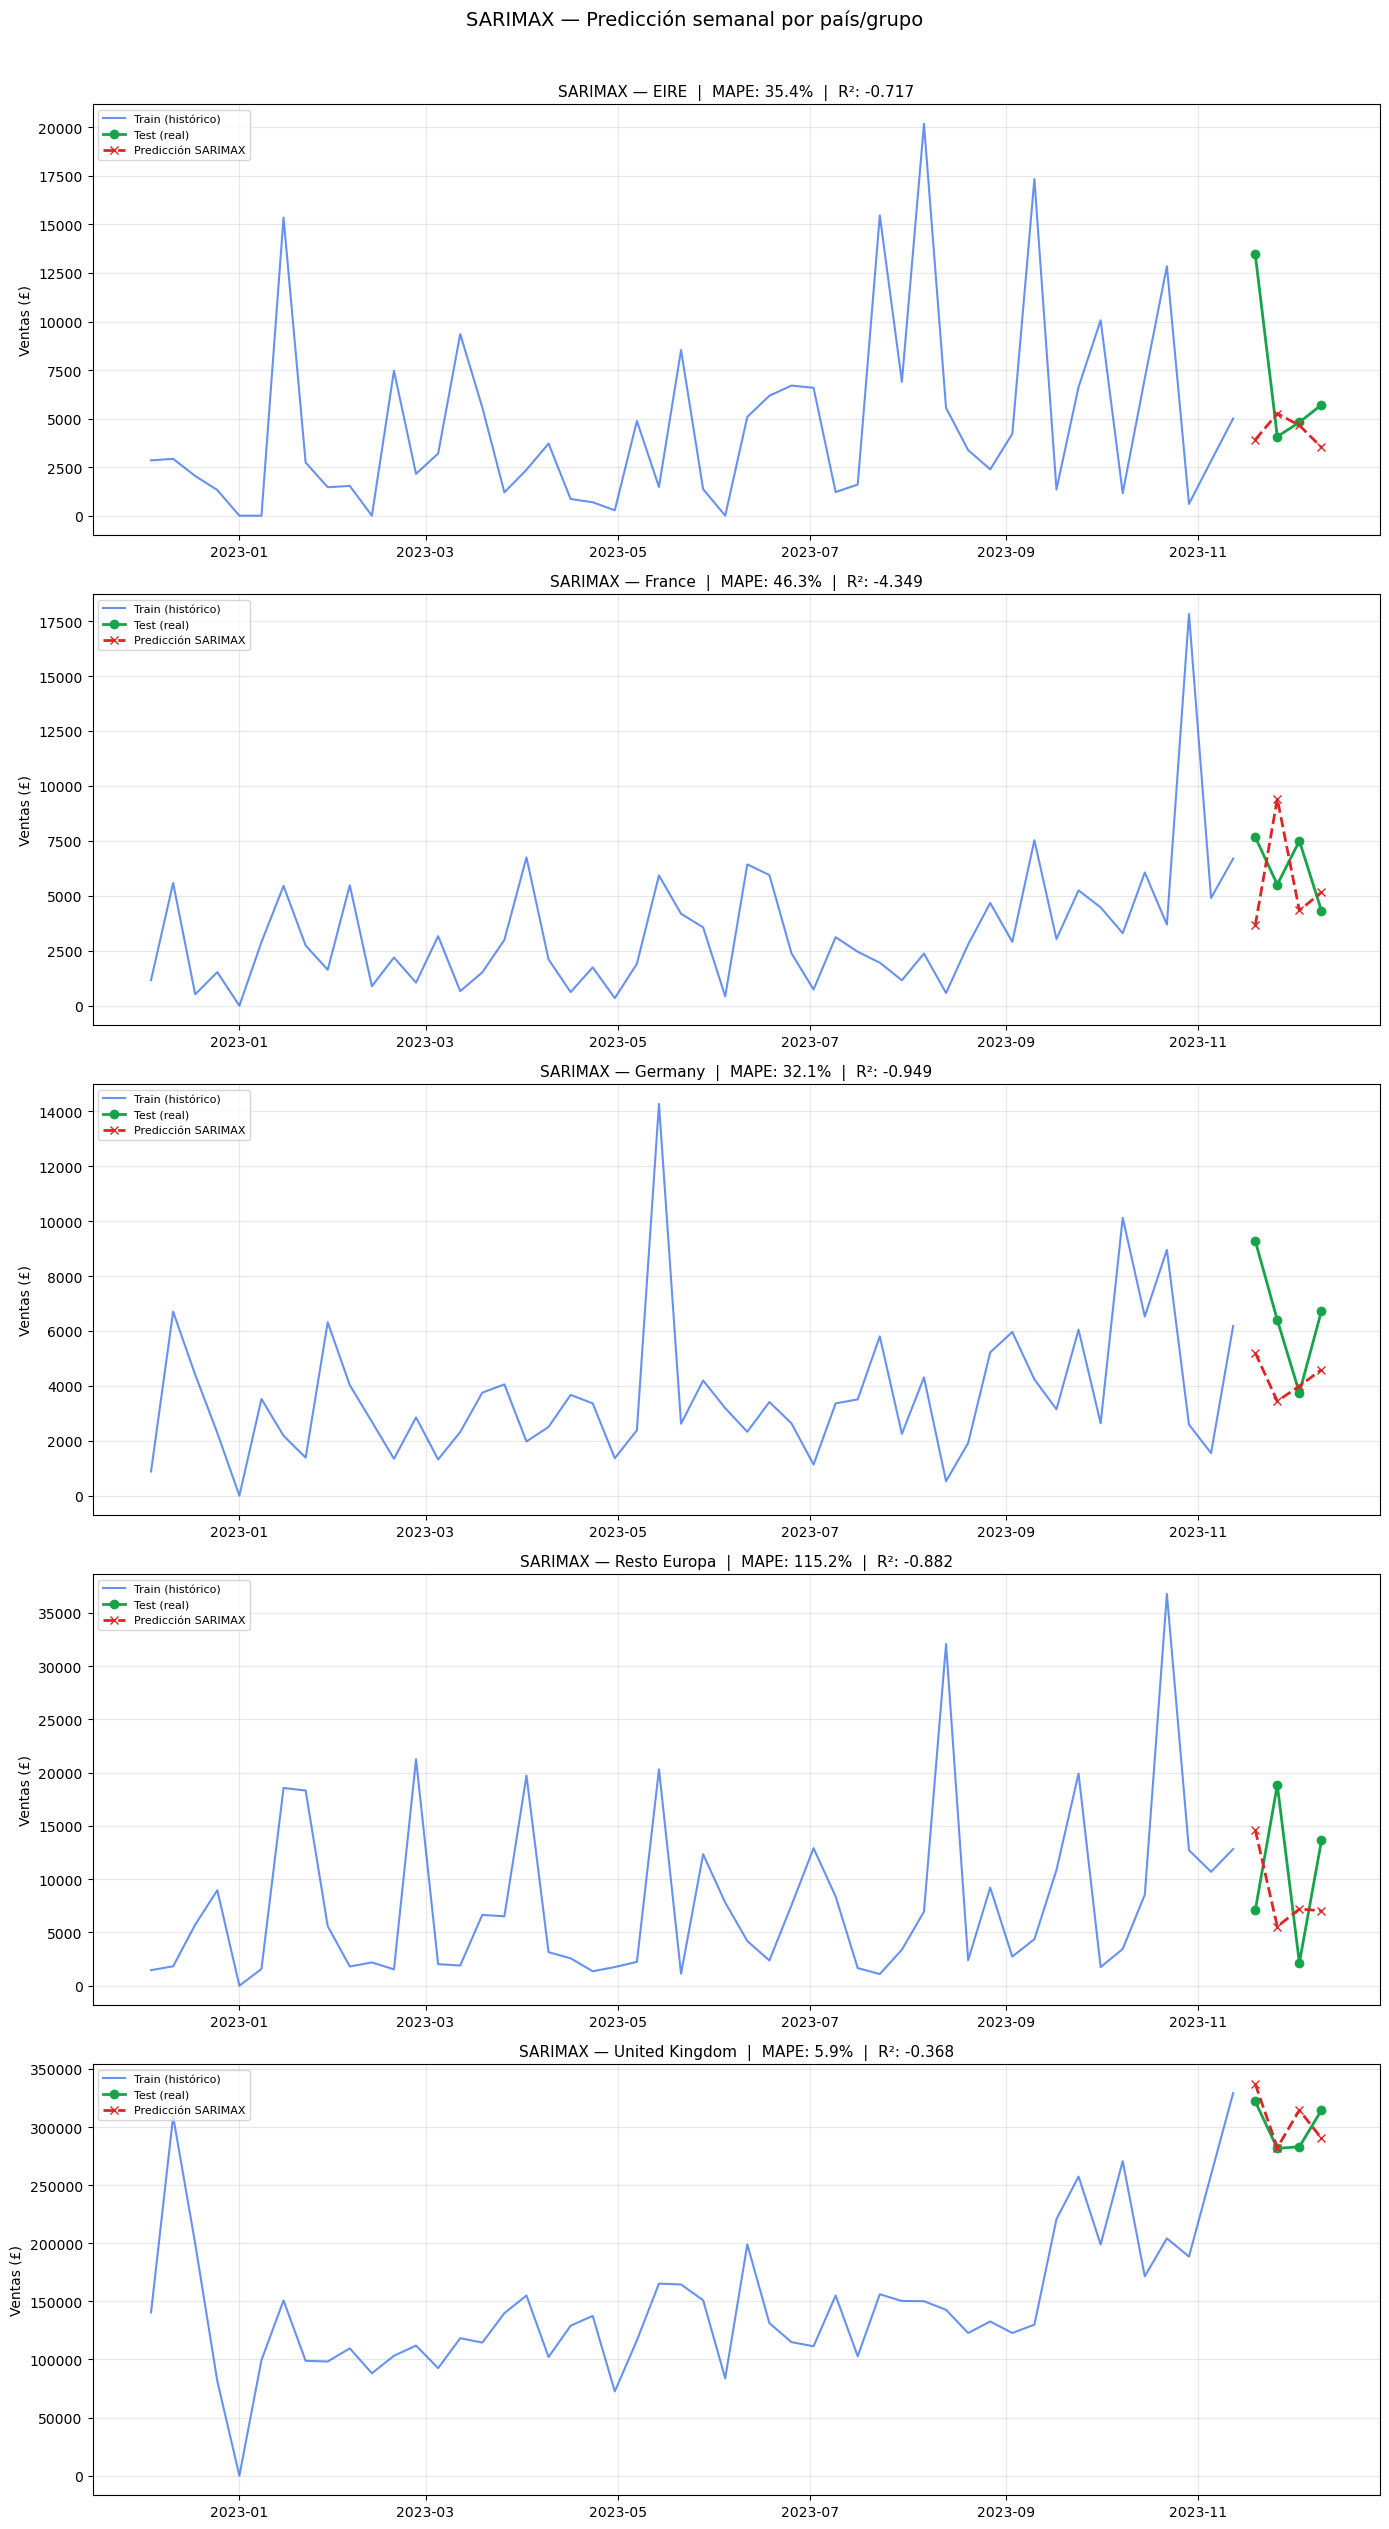

In [47]:
# GRÁFICOS POR PAÍS
fig, axes = plt.subplots(len(GRUPOS), 1, figsize=(14, 5 * len(GRUPOS)))

for i, grupo in enumerate(GRUPOS):
    ax  = axes[i]
    res = resultados_sarimax[grupo]

    # Histórico train
    ax.plot(res['serie_train'].index, res['serie_train'].values,
            label='Train (histórico)', color='#2563EB', linewidth=1.5, alpha=0.7)

    # Test real
    ax.plot(res['serie_test'].index, res['serie_test'].values,
            label='Test (real)', color='#16A34A', linewidth=2, marker='o')

    # Predicción
    ax.plot(res['prediccion'].index, res['prediccion'].values,
            label='Predicción SARIMAX', color='#DC2626',
            linewidth=2, linestyle='--', marker='x')

    mape = res['metricas']['MAPE']
    r2   = res['metricas']['R2']
    ax.set_title(f"SARIMAX — {grupo}  |  MAPE: {mape:.1f}%  |  R²: {r2:.3f}", fontsize=11)
    ax.set_ylabel("Ventas (£)")
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("SARIMAX — Predicción semanal por país/grupo", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [48]:
# RESUMEN FINAL SARIMAX
resumen_sarimax = []
for grupo in GRUPOS:
    m    = resultados_sarimax[grupo]['metricas']
    pred = resultados_sarimax[grupo]['pred_mensual']
    real = resultados_sarimax[grupo]['real_mensual']
    resumen_sarimax.append({
        "País":         grupo,
        "MAE":          round(m['MAE'], 2),
        "RMSE":         round(m['RMSE'], 2),
        "MAPE (%)":     round(m['MAPE'], 2),
        "R²":           round(m['R2'], 3),
        "Real Mensual": round(real, 0),
        "Pred Mensual": round(pred, 0),
    })

df_resumen_sarimax = pd.DataFrame(resumen_sarimax)

print("  RESUMEN SARIMAX — PREDICCIÓN MENSUAL POR PAÍS")

display(df_resumen_sarimax)

total_real = df_resumen_sarimax['Real Mensual'].sum()
total_pred = df_resumen_sarimax['Pred Mensual'].sum()
print(f"\n  Total real empresa  : £{total_real:>12,.0f}")
print(f"  Total predicho      : £{total_pred:>12,.0f}")
print(f"  Diferencia          : £{total_pred - total_real:>12,.0f}  "
      f"({(total_pred - total_real) / total_real * 100:.1f}%)")

# Guardamos para la comparación final
metricas_sarimax = df_resumen_sarimax.copy()

  RESUMEN SARIMAX — PREDICCIÓN MENSUAL POR PAÍS


,País,MAE,RMSE,MAPE (%),R²,Real Mensual,Pred Mensual
0,EIRE,3272.56,4937.24,35.43,-0.717,28062.0,17343.0
1,France,2985.26,3248.38,46.25,-4.349,25007.0,22554.0
2,Germany,2354.61,2739.21,32.09,-0.949,26171.0,17240.0
3,Resto Europa,8128.73,8704.94,115.25,-0.882,41698.0,34430.0
4,United Kingdom,17859.14,21265.63,5.93,-0.368,1201206.0,1224039.0



  Total real empresa  : £   1,322,144
  Total predicho      : £   1,315,606
  Diferencia          : £      -6,538  (-0.5%)


### Conclusiones SARIMAX

El modelo SARIMAX ha obtenido ha obtenido resultado muy prometedores, supera a Prophet en Reino Unido y Resto Europa, mientras que Prophet es más preciso en los mercados secundarios (Francia, EIRE). Esto sugiere que SARIMAX captura mejor las series con mayor volumen y más observaciones, mientras que Prophet es más robusto ante series cortas e irregulares.

La predicción agregada de £1,315,606 frente a un real de £1,322,144 representa una desviación de apenas el **0.5%**, resultado muy sólido de cara al objetivo de valoración de la empresa.

--------------------------------------

## 2.4 XGBoost

XGBoost es un modelo de gradient boosting que, a diferencia de Prophet y SARIMAX, no modela el tiempo de forma nativa. Para adaptarlo a series temporales transformamos la fecha en features numéricas: componentes del calendario y **lags** (valores pasados de la propia serie). Los lags actúan como memoria del modelo — equivalente al componente autorregresivo de SARIMAX.

Usamos `TimeSeriesSplit` para la validación cruzada, que respeta el orden temporal y evita el data leakage (usar datos futuros para predecir el pasado).

In [49]:
# FUNCIÓN: CREAR FEATURES TEMPORALES Y LAGS
def crear_features_xgb(df_grupo):
    df = df_grupo.copy().sort_values('Semana').reset_index(drop=True)
    
    # Features de calendario
    df['mes']          = df['Semana'].dt.month
    df['trimestre']    = df['Semana'].dt.quarter
    df['semana_año']   = df['Semana'].dt.isocalendar().week.astype(int)
    df['año']          = df['Semana'].dt.year
    df['temporada_alta'] = df['mes'].isin([11, 12]).astype(int)
    
    # Lags — valores pasados de la serie
    df['lag_1'] = df['TotalSales'].shift(1) 
    df['lag_2'] = df['TotalSales'].shift(2)  
    df['lag_4'] = df['TotalSales'].shift(4)  
    df['lag_8'] = df['TotalSales'].shift(8)  
    
    # Media móvil de las últimas 4 semanas (suaviza el ruido)
    df['media_movil_4'] = df['TotalSales'].shift(1).rolling(4).mean()
    
    return df
#Inicialmente probé con las features que tengo en la linea de codigo siguiente, pero tras una pasada inical al modelo, me quedé con menos ya que tienen importancia muy baja o 0
#FEATURES = ['mes', 'trimestre', 'semana_año', 'año', 'temporada_alta','lag_1', 'lag_2', 'lag_4', 'lag_8', 'media_movil_4']

FEATURES = ['semana_año', 'mes', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'media_movil_4']

In [50]:
# FUNCIÓN PARA XGBOOST
def entrenar_xgboost(df_train_grupo, df_test_grupo, grupo):
   
    # CREAR FEATURES
    # Combino train + test para que los lags del test se calculen correctamente (sin "ver el futuro")
    df_completo = pd.concat([df_train_grupo, df_test_grupo]).sort_values('Semana')
    df_features = crear_features_xgb(df_completo)
    df_features = df_features.dropna(subset=FEATURES)
    
    # TRAIN / TEST
    fecha_corte = df_test_grupo['Semana'].min()
    train_feat = df_features[df_features['Semana'] < fecha_corte]
    test_feat  = df_features[df_features['Semana'] >= fecha_corte]
    
    X_train = train_feat[FEATURES]
    y_train = train_feat['TotalSales']
    X_test  = test_feat[FEATURES]
    y_test  = test_feat['TotalSales']
    
    # ENTRENAMIENTO
    modelo = xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,        
        objective='reg:squarederror',
        random_state=42,
        verbosity=0
    )
    modelo.fit(X_train, y_train)
    
    # PREDICCIÓN
    y_pred = modelo.predict(X_test)
    
    # MÉTRICAS
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    r2   = r2_score(y_test, y_pred)
    
    pred_mensual = y_pred.sum()
    real_mensual = y_test.values.sum()
    
    print(f"  {grupo:<20} MAPE: {mape:.1f}%")
    
    return {
        "modelo":      modelo,
        "X_train":     X_train,
        "X_test":      X_test,
        "y_test":      y_test,
        "y_pred":      y_pred,
        "semanas_test": test_feat['Semana'],
        "semanas_train": train_feat['Semana'],
        "y_train":     y_train,
        "metricas":    {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2},
        "pred_mensual": pred_mensual,
        "real_mensual": real_mensual,
    }

In [51]:
# ENTRENAMIENTO PARA TODOS LOS PAÍSES
resultados_xgb = {}
GRUPOS = list(df_train['Country'].unique())

print("Entrenando XGBoost por país\n")
for grupo in GRUPOS:
    df_train_grupo = df_train[df_train['Country'] == grupo].copy()
    df_test_grupo  = df_test[df_test['Country'] == grupo].copy()
    resultados_xgb[grupo] = entrenar_xgboost(df_train_grupo, df_test_grupo, grupo)


Entrenando XGBoost por país

  EIRE                 MAPE: 23.4%
  France               MAPE: 21.7%
  Germany              MAPE: 27.8%
  Resto Europa         MAPE: 158.0%
  United Kingdom       MAPE: 11.3%


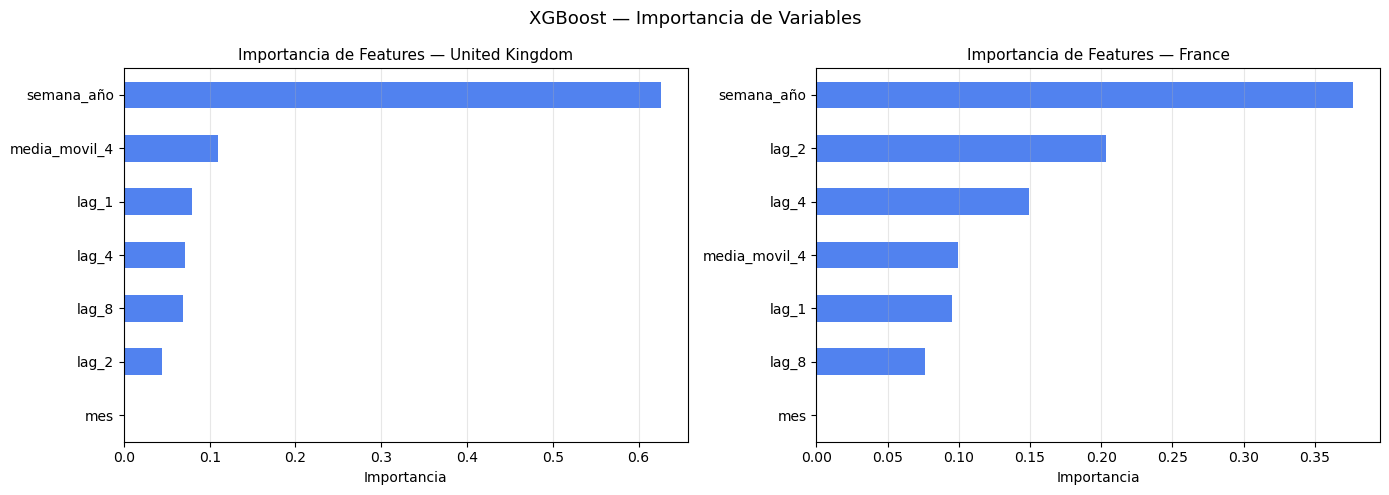

In [52]:
# ── IMPORTANCIA DE FEATURES — UK como ejemplo representativo, nos dice qué variables ha usado más el modelo para predecir
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, grupo in zip(axes, ['United Kingdom', 'France']):
    res = resultados_xgb[grupo]
    importancias = pd.Series(
        res['modelo'].feature_importances_,
        index=FEATURES
    ).sort_values(ascending=True)

    importancias.plot(kind='barh', ax=ax, color='#2563EB', alpha=0.8)
    ax.set_title(f'Importancia de Features — {grupo}', fontsize=11)
    ax.set_xlabel('Importancia')
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('XGBoost — Importancia de Variables', fontsize=13)
plt.tight_layout()
plt.show()

### Importancia de Features — XGBoost

Estos gráficos dicen qué features está usando realmente el modelo.

La variable más influyente en ambos mercados es `semana_año`, que captura el patrón estacional anual — semanas 48-52 corresponden al pico navideño y semanas 1-4 al valle post-navideño. Esto explica por qué `temporada_alta` resultó redundante y fue eliminada (tal y como lo comenté cuando definí las #FEATURES)

Los lags y la media móvil ocupan el segundo nivel de importancia, confirmando la dependencia autorregresiva detectada en el análisis ACF/PACF del Bloque 1. El modelo está aprendiendo tanto *cuándo* estamos en el año como *cuánto* se vendió recientemente.

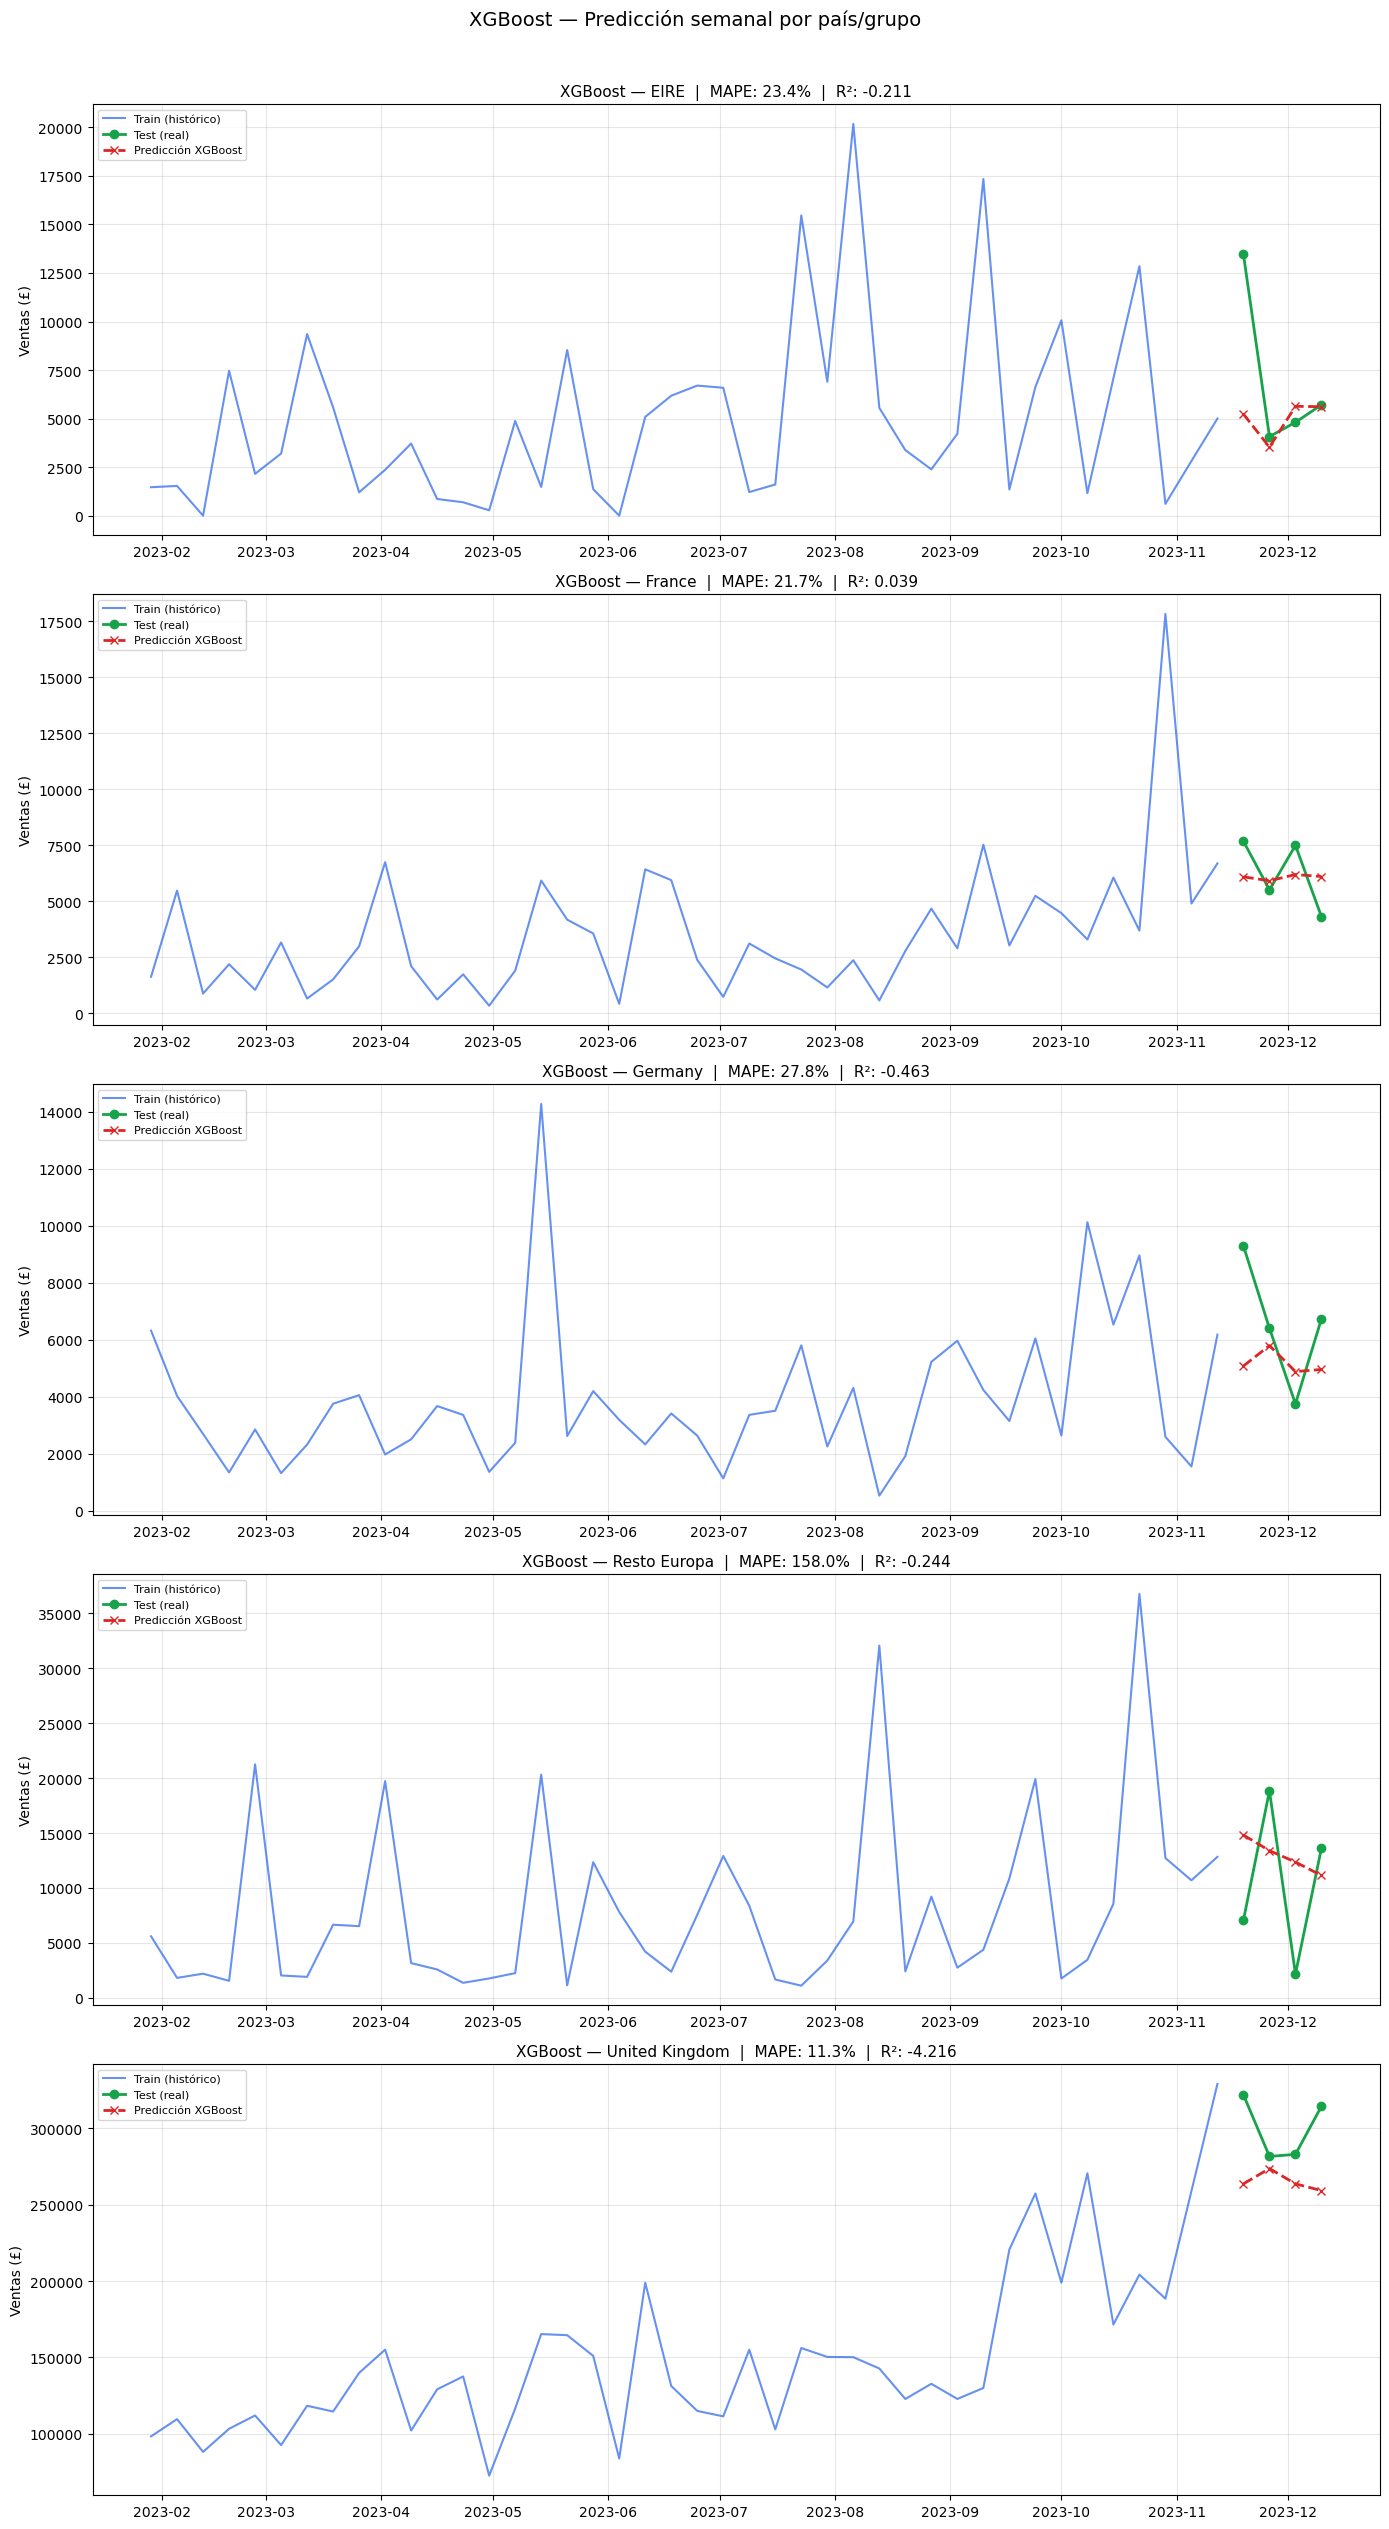

════════════════════════════════════════════════════════════════════════════════
  RESUMEN XGBOOST — PREDICCIÓN MENSUAL POR PAÍS
════════════════════════════════════════════════════════════════════════════════


,País,MAE,RMSE,MAPE (%),R²,Real Mensual,Pred Mensual
0,EIRE,2425.53,4146.21,23.35,-0.211,28062.0,20009.0
1,France,1271.34,1377.08,21.72,0.039,25007.0,24315.0
2,Germany,1931.20,2373.45,27.85,-0.463,26171.0,20712.0
3,Resto Europa,6480.29,7076.79,158.02,-0.244,41698.0,51694.0
4,United Kingdom,35215.05,41517.35,11.33,-4.216,1201206.0,1060346.0



  Total real empresa  : £   1,322,144
  Total predicho      : £   1,177,076
  Diferencia          : £    -145,068  (-11.0%)


In [53]:
# GRÁFICOS POR PAÍS
fig, axes = plt.subplots(len(GRUPOS), 1, figsize=(14, 5 * len(GRUPOS)))

for i, grupo in enumerate(GRUPOS):
    ax  = axes[i]
    res = resultados_xgb[grupo]

    ax.plot(res['semanas_train'], res['y_train'],
            label='Train (histórico)', color='#2563EB', linewidth=1.5, alpha=0.7)
    ax.plot(res['semanas_test'], res['y_test'],
            label='Test (real)', color='#16A34A', linewidth=2, marker='o')
    ax.plot(res['semanas_test'], res['y_pred'],
            label='Predicción XGBoost', color='#DC2626',
            linewidth=2, linestyle='--', marker='x')

    mape = res['metricas']['MAPE']
    r2   = res['metricas']['R2']
    ax.set_title(f"XGBoost — {grupo}  |  MAPE: {mape:.1f}%  |  R²: {r2:.3f}", fontsize=11)
    ax.set_ylabel("Ventas (£)")
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("XGBoost — Predicción semanal por país/grupo", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# RESUMEN FINAL XGBOOST
resumen_xgb = []
for grupo in GRUPOS:
    m    = resultados_xgb[grupo]['metricas']
    pred = resultados_xgb[grupo]['pred_mensual']
    real = resultados_xgb[grupo]['real_mensual']
    resumen_xgb.append({
        "País":         grupo,
        "MAE":          round(m['MAE'], 2),
        "RMSE":         round(m['RMSE'], 2),
        "MAPE (%)":     round(m['MAPE'], 2),
        "R²":           round(m['R2'], 3),
        "Real Mensual": round(real, 0),
        "Pred Mensual": round(pred, 0),
    })

df_resumen_xgb = pd.DataFrame(resumen_xgb)
print("═" * 80)
print("  RESUMEN XGBOOST — PREDICCIÓN MENSUAL POR PAÍS")
print("═" * 80)
display(df_resumen_xgb)

total_real = df_resumen_xgb['Real Mensual'].sum()
total_pred = df_resumen_xgb['Pred Mensual'].sum()
print(f"\n  Total real empresa  : £{total_real:>12,.0f}")
print(f"  Total predicho      : £{total_pred:>12,.0f}")
print(f"  Diferencia          : £{total_pred - total_real:>12,.0f}  "
      f"({(total_pred - total_real) / total_real * 100:.1f}%)")

metricas_xgb = df_resumen_xgb.copy()

### Conclusiones XGBoost

El modelo XGBoost ha obtenido ha obtenido resultados aceptables, modelos como Prophet y SARIMAX capturan mejor el rusltado en el pais más improtante como es Reino Unido, y tambien en el Resto de Europa y en el total de la empresa. XGBoost sin embargo, ha mostrado mejores resultados en paises como Francia, EIRE y Germany.

La predicción agregada de £1,177,076 frente a un real de £1,322,144 representa una desviación del **11%**

Lo más destacado de este modelo es, como hemos explicado anteriormente, la importancia de la FEATURES para aplicar el modelo.

----------------------------


# 3. ANÁLSIS DE RESULTADOS Y SELECCIÓN DEL MODELO A APLICAR

## 3.1 Comparativa de Modelos

Después de ver como los 3 modelos, tras entrenarlos con los datos que disponemos, vamos hacer una comparativa de que modelos obtiene mejores resultados para las 4 ultimas semanas de datos (1 mes) donde si tenemos los resultados reales, y por tanto podemos ver la efectividad de como acierta o no cada modelo predictivo.

Para medir esa efectividad, vamos a usar la métrica de **MAPE (Error Porcentual Absoluto Medio)**, que lo que hace es, medir en porcentaje la distancia promedio entre las predicciones de tu modelo y los datos reales.

In [54]:
# TABLA COMPARATIVA
comparativa = []

for grupo in GRUPOS:
    comparativa.append({
        "País":              grupo,
        "MAPE Prophet (%)":  round(resultados_prophet[grupo]['metricas']['MAPE'], 2),
        "MAPE SARIMAX (%)":  round(resultados_sarimax[grupo]['metricas']['MAPE'], 2),
        "MAPE XGBoost (%)":  round(resultados_xgb[grupo]['metricas']['MAPE'], 2),
    })

df_comparativa = pd.DataFrame(comparativa)

# Resaltamos el mejor modelo por país
def resaltar_minimo(row):
    cols = ['MAPE Prophet (%)', 'MAPE SARIMAX (%)', 'MAPE XGBoost (%)']
    min_val = row[cols].min()
    return ['background-color: #16A34A; color: white' 
            if row[c] == min_val else '' for c in row.index]

print("═" * 65)
print("  COMPARATIVA MAPE (%) POR MODELO Y PAÍS — menor es mejor")
print("═" * 65)
display(df_comparativa.style.format({
    'MAPE Prophet (%)': '{:.2f}',
    'MAPE SARIMAX (%)': '{:.2f}',
    'MAPE XGBoost (%)': '{:.2f}'
}).apply(resaltar_minimo, axis=1))

# Totales empresa
print("\n TOTAL EMPRESA ")
modelos = {
    "Prophet":  metricas_prophet,
    "SARIMAX":  metricas_sarimax,
    "XGBoost":  metricas_xgb,
}
for nombre, df_m in modelos.items():
    real  = df_m['Real Mensual'].sum()
    pred  = df_m['Pred Mensual'].sum()
    error = (pred - real) / real * 100
    print(f"  {nombre:<10} Real: £{real:>12,.0f} | "
          f"Pred: £{pred:>12,.0f} | Error: {error:>+.1f}%")

═════════════════════════════════════════════════════════════════
  COMPARATIVA MAPE (%) POR MODELO Y PAÍS — menor es mejor
═════════════════════════════════════════════════════════════════


,País,MAPE Prophet (%),MAPE SARIMAX (%),MAPE XGBoost (%)
0,EIRE,28.28,35.43,23.35
1,France,23.89,46.25,21.72
2,Germany,30.91,32.09,27.85
3,Resto Europa,129.24,115.25,158.02
4,United Kingdom,6.41,5.93,11.33



 TOTAL EMPRESA 
  Prophet    Real: £   1,322,144 | Pred: £   1,361,491 | Error: +3.0%
  SARIMAX    Real: £   1,322,144 | Pred: £   1,315,606 | Error: -0.5%
  XGBoost    Real: £   1,322,144 | Pred: £   1,177,076 | Error: -11.0%


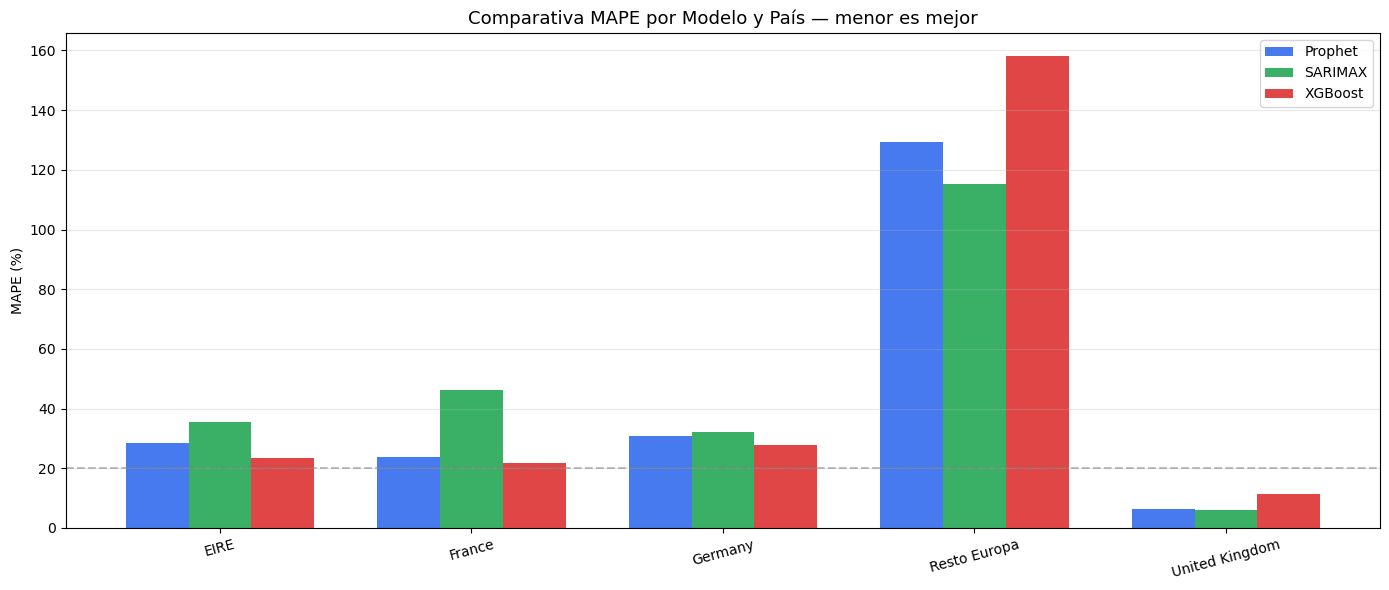

In [55]:
# GRÁFICO COMPARATIVO
fig, ax = plt.subplots(figsize=(14, 6))

x = range(len(GRUPOS))
width = 0.25

bars1 = ax.bar([i - width for i in x], df_comparativa['MAPE Prophet (%)'],
               width, label='Prophet', color='#2563EB', alpha=0.85)
bars2 = ax.bar([i for i in x], df_comparativa['MAPE SARIMAX (%)'],
               width, label='SARIMAX', color='#16A34A', alpha=0.85)
bars3 = ax.bar([i + width for i in x], df_comparativa['MAPE XGBoost (%)'],
               width, label='XGBoost', color='#DC2626', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(GRUPOS, rotation=15)
ax.set_ylabel('MAPE (%)')
ax.set_title('Comparativa MAPE por Modelo y País — menor es mejor', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(20, linestyle='--', color='gray', alpha=0.5, label='Umbral 20%')

plt.tight_layout()
plt.show()

## 3.2 SELECCIÓN DEL MODELO Y CONCLUSIONES DE COMPARACIÓN

Tras someter los tres algoritmos (SARIMAX, Prophet y XGBoost) a las mismas condiciones de evaluación, la conclusión es clara: no existe un único modelo perfecto que entienda por igual a todos los países. Por este motivo, he decidido aplciar la estrategia más robusta y fiable para TodoVentas S.A., y hacer un enfoque híbrido. Voy a seleccionar el modelo con el menor margen de error (MAPE) para cada mercado específico y sumar sus resultados.

Esta decisión se fundamenta en dos pilares estratégicos:

- **Adaptación a los mercados diferentes de cada pais:** El modelo se adapta al país, no el país al modelo. Reino Unido concentra el 88.6% del volumen total de ventas, esto provoca que el modelo que mejor se adapte a este país tenga una fuerte influencia en la toma de decisión, pero al seleccionar los algoritmos de forma aislada, evitamos forzar a que ese mismo modelo intente predecir mercados con volúmenes y "personalidades" totalmente distintas, como Francia o Alemania.

- **Visión global de máxima fidelidad (Suma de expertos):** En lugar de crear un único modelo masivo que promedie y diluya los errores de todos los territorios, la estrategia de seleccionar al "ganador" por región nos garantiza la predicción agregada más precisa a nivel corporativo. Al sumar las piezas individuales mejor optimizadas, obtenemos el escenario global más realista y ajustado a la realidad.

Por tanto, la selección de los modelos será:

| País | Modelo seleccionado | MAPE en test |
|---|---|---|
| United Kingdom | SARIMAX | 5.9% |
| Resto Europa | SARIMAX | 115.3% |
| Germany | XGBoost | 27.9% |
| EIRE | XGBoost | 23.4% |
| France | XGBoost | 21.7% |


-------------------------------

# 4. PREDICCIÓN FINAL - DEL 11/12/2023 AL 7/01/2024

Ahora, el proceso que voy a realizar es reentrenar con **todos los datos disponibles** (sin reservar test) para maximizar la información utilizada y realizar la predicción real de las 4 semanas siguientes a los datos.

Como estos modelos, con solo un año de datos, no es capaz de predecir el cierre de la empresa por navidad, así que se lo tenemos que poner manualmente para mejorar la predicción y fijar las fechas donde la empresa está cerrada.

In [56]:
# ── PREDICCIÓN ENERO 2024 — ENSEMBLE POR SELECCIÓN ────────────────────────────

# ── CIERRE NAVIDEÑO ───────────────────────────────────────────────────────────
# Se por el EDA que la empresa cierra del 24 dic al 3 enero
# Fuerzo a 0 las semanas donde más de la mitad de los días están cerrados
DIAS_CIERRE = pd.date_range("2023-12-24", "2024-01-03")

def aplicar_cierre_navidad(pred_series):
    pred_ajustada = pred_series.copy()
    for fecha in pred_series.index:
        dias_semana  = pd.date_range(end=fecha, periods=7)
        dias_cerrados = sum(1 for d in dias_semana if d in DIAS_CIERRE)
        if dias_cerrados >= 4:
            pred_ajustada[fecha] = 0
    return pred_ajustada

# Definimos qué modelo usar para cada país
MODELO_POR_PAIS = {
    'United Kingdom': 'SARIMAX',
    'Resto Europa':   'SARIMAX',
    'Germany':        'XGBoost',
    'EIRE':           'XGBoost',
    'France':         'XGBoost',
}

prediccion_ensemble = {}

for grupo, modelo_elegido in MODELO_POR_PAIS.items():

    # Datos completos del grupo
    df_grupo_completo = df_estandarizado[
        df_estandarizado['Country'] == grupo
    ].copy()
    serie_completa = df_grupo_completo.set_index('Semana')['TotalSales']
    ultima_fecha   = serie_completa.index.max()

    # Fechas futuras — 4 semanas
    fechas_futuras = pd.date_range(
        start=ultima_fecha + pd.Timedelta(weeks=1),
        periods=4,
        freq='W'
    )

    # ── SARIMAX ───────────────────────────────────────────────────────────────
    if modelo_elegido == 'SARIMAX':
        exog_completo = crear_exog(serie_completa.index)
        exog_futuro   = crear_exog(fechas_futuras)

        modelo_ant = resultados_sarimax[grupo]['modelo']
        p, d, q    = modelo_ant.model.order
        P, D, Q, s = modelo_ant.model.seasonal_order

        modelo_final = SARIMAX(
            serie_completa,
            exog=exog_completo,
            order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        pred = modelo_final.predict(
            start=len(serie_completa),
            end=len(serie_completa) + 3,
            exog=exog_futuro,
            typ='levels'
        )
        pred.index = fechas_futuras

    # ── XGBOOST ───────────────────────────────────────────────────────────────
    elif modelo_elegido == 'XGBoost':
        df_grupo_features = crear_features_xgb(
            serie_completa.reset_index()
        ).dropna(subset=FEATURES)

        X_full = df_grupo_features[FEATURES]
        y_full = df_grupo_features['TotalSales']

        modelo_xgb_final = xgb.XGBRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            objective='reg:squarederror',
            random_state=42,
            verbosity=0
        )
        modelo_xgb_final.fit(X_full, y_full)

        futuro_df = pd.DataFrame({
            'Semana':     fechas_futuras,
            'TotalSales': 0
        })
        df_completo_xgb = pd.concat([
            serie_completa.reset_index(),
            futuro_df
        ]).reset_index(drop=True)

        futuro_features = crear_features_xgb(
            df_completo_xgb
        ).tail(4)[FEATURES]

        pred_values = modelo_xgb_final.predict(futuro_features)
        pred = pd.Series(pred_values, index=fechas_futuras)

    # ── APLICAMOS CIERRE NAVIDEÑO ─────────────────────────────────────────────
    pred = aplicar_cierre_navidad(pred)

    # ── GUARDAMOS RESULTADO ───────────────────────────────────────────────────
    prediccion_ensemble[grupo] = {
        'modelo_usado': modelo_elegido,
        'prediccion':   pred,
        'pred_enero':   pred.sum(),
    }

    print(f" {grupo:<20} [{modelo_elegido:<8}] "
          f"Predicción próximo mes: £{pred.sum():>12,.0f}")

# Total empresa
total = sum(v['pred_enero'] for v in prediccion_ensemble.values())
print(f"\n{'═'*55}")
print(f"  TOTAL EMPRESA próximo mes: £{total:>12,.0f}")
print(f"{'═'*55}")

 United Kingdom       [SARIMAX ] Predicción próximo mes: £     826,997
 Resto Europa         [SARIMAX ] Predicción próximo mes: £      27,657
 Germany              [XGBoost ] Predicción próximo mes: £      20,319
 EIRE                 [XGBoost ] Predicción próximo mes: £      17,127
 France               [XGBoost ] Predicción próximo mes: £      20,129

═══════════════════════════════════════════════════════
  TOTAL EMPRESA próximo mes: £     912,230
═══════════════════════════════════════════════════════


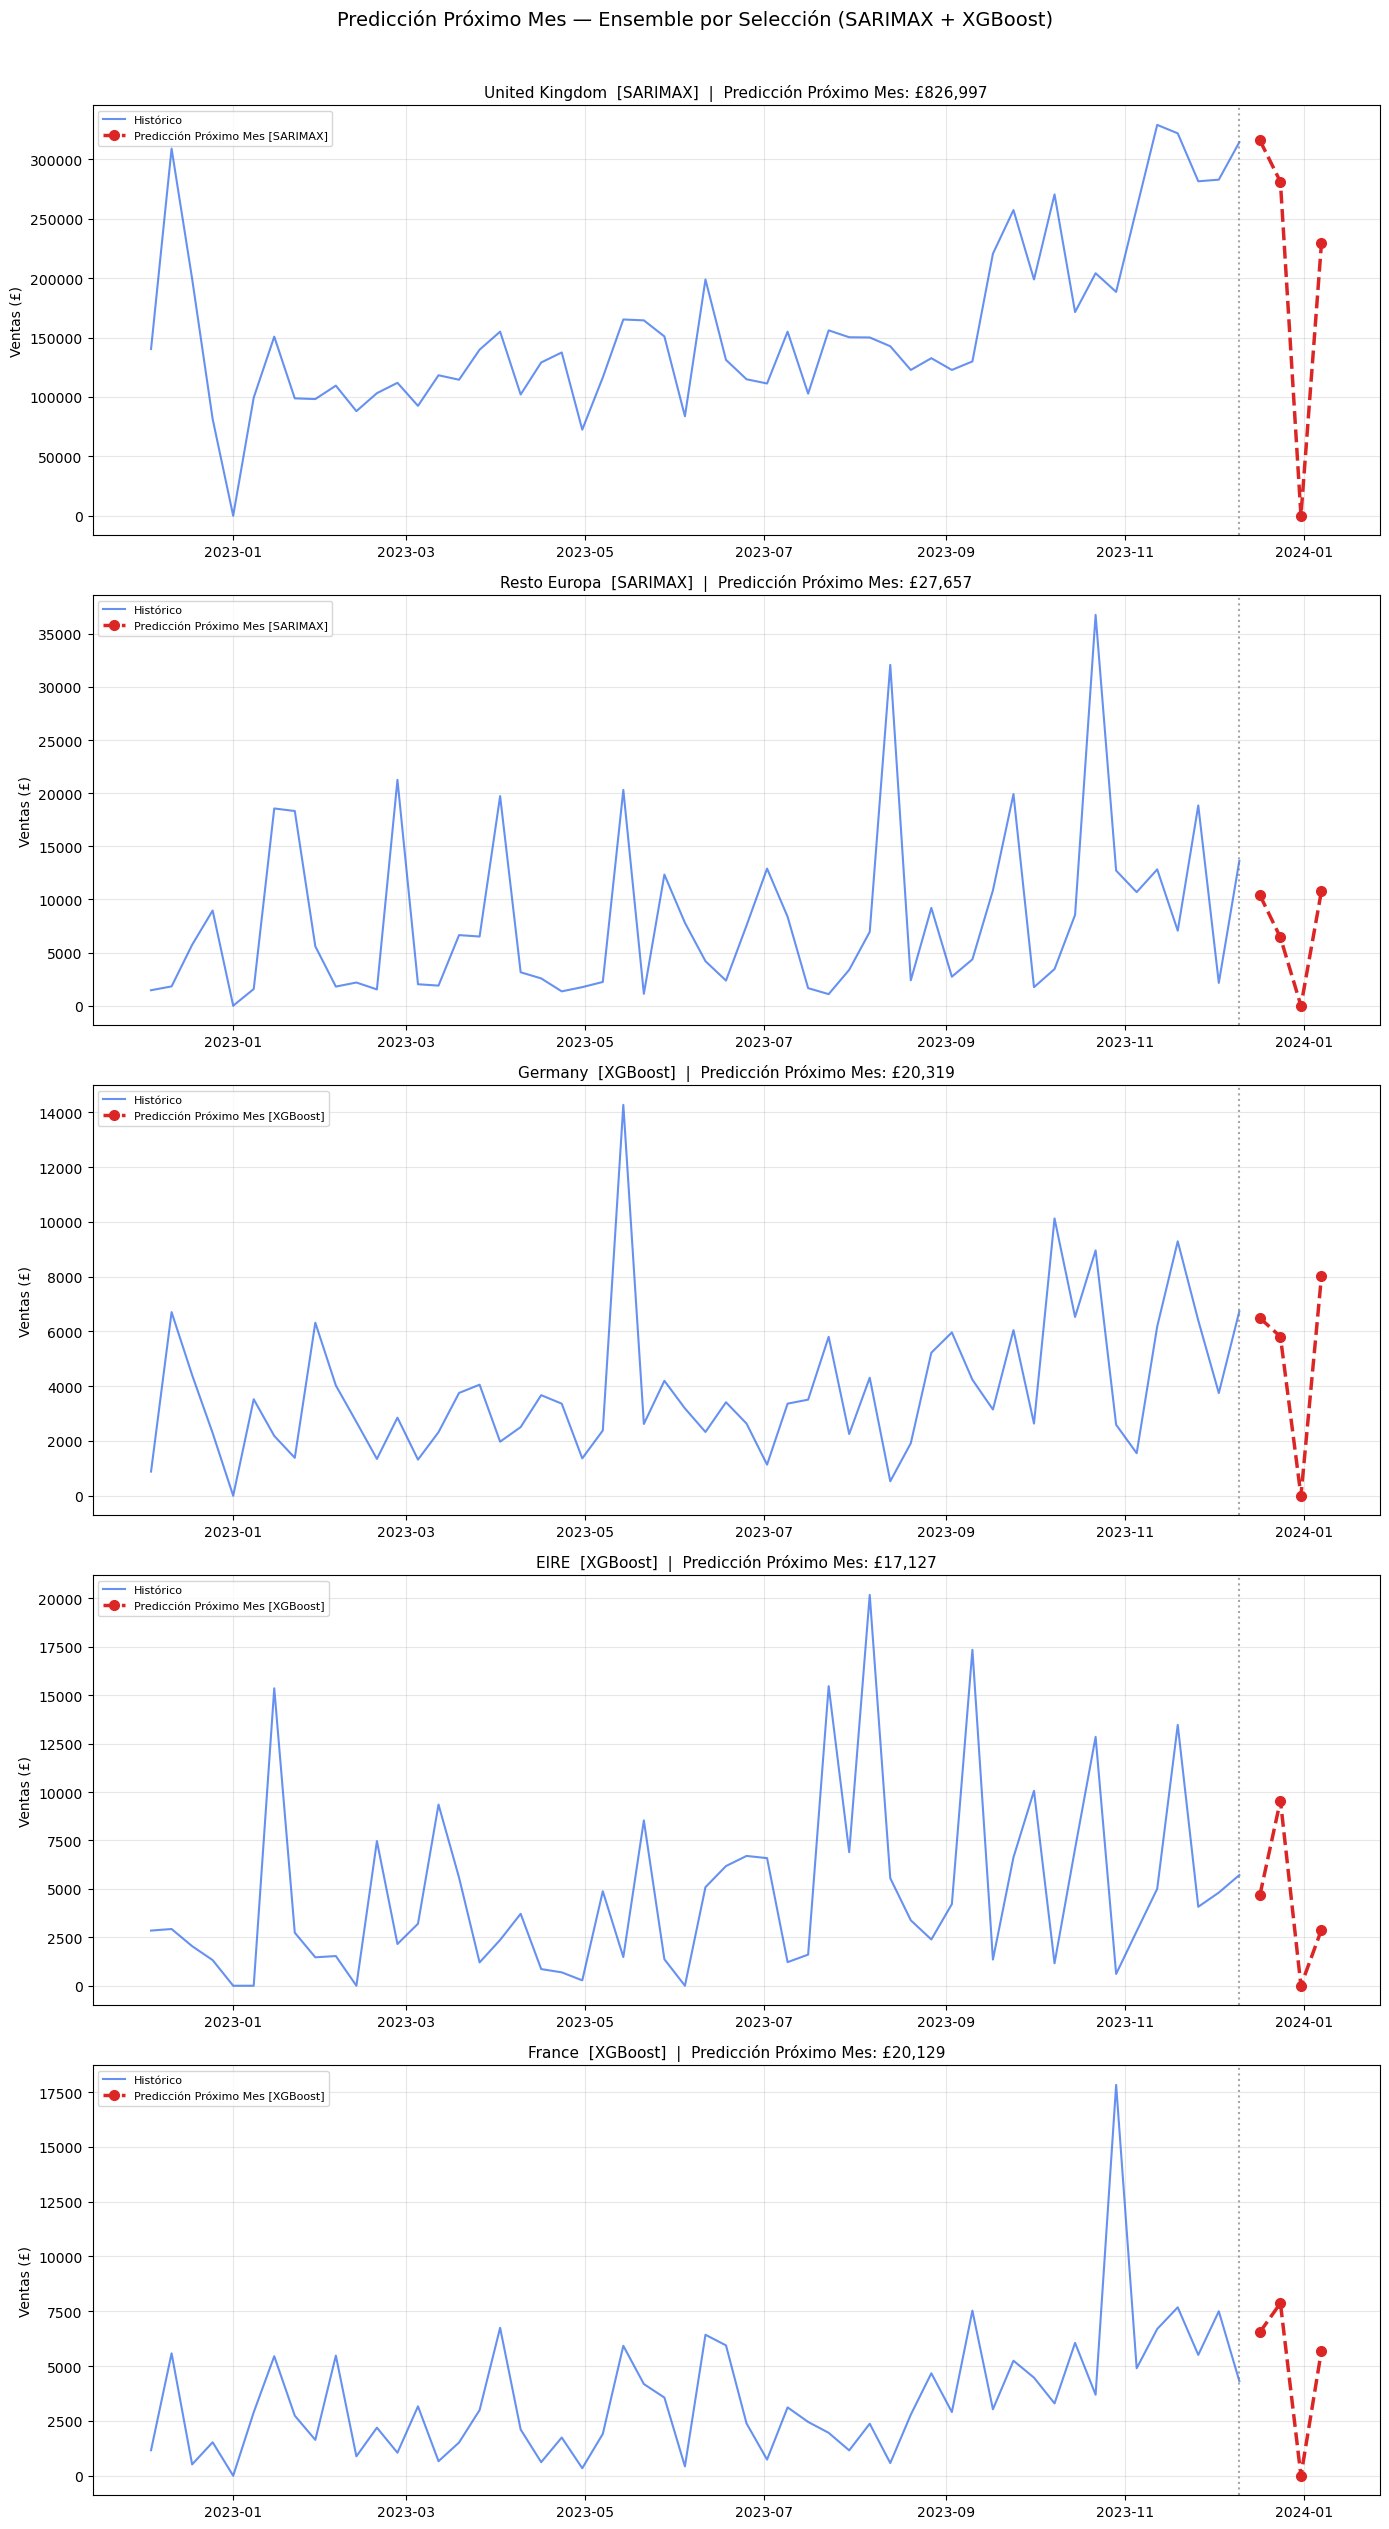

In [57]:
# ── GRÁFICO PREDICCIÓN ─────────────────────────────────────────────
fig, axes = plt.subplots(len(MODELO_POR_PAIS), 1,
                         figsize=(14, 5 * len(MODELO_POR_PAIS)))

for i, (grupo, res) in enumerate(prediccion_ensemble.items()):
    ax = axes[i]

    # Histórico completo
    serie = df_estandarizado[
        df_estandarizado['Country'] == grupo
    ].set_index('Semana')['TotalSales']

    ax.plot(serie.index, serie.values,
            label='Histórico', color='#2563EB',
            linewidth=1.5, alpha=0.7)

    # Predicción proximo mes
    ax.plot(res['prediccion'].index, res['prediccion'].values,
            label=f"Predicción Próximo Mes [{res['modelo_usado']}]",
            color='#DC2626', linewidth=2.5,
            linestyle='--', marker='o', markersize=7)

    # Línea de separación histórico/predicción
    ax.axvline(serie.index.max(),
               color='gray', linestyle=':', alpha=0.7)

    ax.set_title(
        f"{grupo}  [{res['modelo_usado']}]  |  "
        f"Predicción Próximo Mes: £{res['pred_enero']:,.0f}",
        fontsize=11
    )
    ax.set_ylabel("Ventas (£)")
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Predicción Próximo Mes — Ensemble por Selección (SARIMAX + XGBoost)",
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.show()

----------------------

# 5. CONCLUSIONES FINALES

Una vez realizadola estimación con los modelos SARIMAX y XGBoost con el histórico completo (dic 2022 – dic 2023), la predicción de ventas para el próximo mes (desde 11/12/2023 al 07/01/2023) es:

| País | Predicción próximo mes (4 semanas) |
|---|---|
| United Kingdom | £826,997 |
| France | £20,129 |
| EIRE | £17,127 |
| Germany | £20,319 |
| Resto Europa | £27,657 |
| **TOTAL EMPRESA** | **£912,230** |

Enero es históricamente el mes más flojo del año para TodoVentas S.A. debido al valle post-navideño identificado en el EDA. La predicción de £912,230 es coherente con este patrón — representa una caída respecto a los meses de noviembre-diciembre, que son los de mayor actividad, y por el parón navideño de la empresa, pero se mantiene en línea con la tendencia ascendente anual identificada en la descomposición de la serie.

**NOTA**: Previamente, he probado el modelo aplicando SARIMAX a todos los datos, y hay una diferencia de £18,305, lo que equivale a 1,5% de incremento de los algoritmos finalmente utilizados.


## 5.1 HALLAZGOS SACADOS DEL PROYECTO

- El negocio está creciendo (Tendencia positiva): Las ventas muestran una clara línea ascendente a lo largo del tiempo. Esto refleja que la empresa está en plena expansión, lo cual es un escenario ideal para justificar futuras ampliaciones de capital.

- Fuerte estacionalidad a final de año (Q4): Los meses de octubre, noviembre y principios de diciembre son el gran motor económico del año, impulsados por el Black Friday y las compras previas a la Navidad. Sin embargo, es vital tener en cuenta que a finales de diciembre las ventas caen a cero debido al cierre vacacional de la empresa, un factor crucial para la planificación logística.

- Alta dependencia del mercado británico: casi el 90% de los ingresos provienen del Reino Unido. Aunque esto demuestra una posición muy sólida y dominancia en ese país, también señala el siguiente paso lógico para la empresa: diversificarse hacia otros países europeos para no depender de un solo mercado y minimizar riesgos.

- Comportamiento de venta: La mayor actividad de compras ocurre siempre de lunes a jueves, con caídas drásticas durante los fines de semana. Este es el patrón clásico de clientes que compran para sus propios negocios (B2B) durante su horario laboral habitual.

## 5.2 LIMITACIONES

- Al tener **un único año de histórico** (dic 2022 – dic 2023), el modelo no es capaz de indentificar por si solo las vacaciones, y por tanto definir esas fechas como periodo de no actividad, y por tanto, tenemos que incluirlas manuelamente.

- El MAPE, en algunos casos es considerablemente alto (25%/30%) lo que no permite tener una alta confianza de los resultados predichos, y en el caso del grupo de Resto de Europa, con un MAPE de 115%, la previsión no debe ser tomada con ninguna fiabilidad.

- Por el contrario, en Reino Unido, al conseguir un MAPE de 5,9% (se califica como preciso) podemos hacer una estimación real de ventas ya que este país concentra más del 80% de las ventas de la empresa.

- Debido a que el grupo de Resto de Europa (España, Portugal, Italia, Bélgica y Suecia), con una falta de información 

- El modelo está entrenado con **un único año de histórico** (dic 2022 – dic 2023). Con más datos la fiabilidad mejoraría significativamente.


## 5.3 RECOMENDACIONES ESTRATÉGICAS

- **Planificación de capacidad en Q4**: anticipar el pico estacional con refuerzo logístico e inventario desde septiembre.
- **Diversificación geográfica**: los mercados secundarios (Alemania, Irlanda (EIRE), Francia) muestran potencial que podría reducir la dependencia del mercado británico.
- **Actualización del modelo**: reentrenar mensualmente con nuevos datos para mantener la precisión predictiva.
- **Integración con planificación financiera**: usar estas predicciones como input en los modelos de valoración para el proceso de ampliación de capital.